<a href="https://colab.research.google.com/github/Shihab7u/Brain-Tumor-Classification/blob/main/CovNet_(Datase_3)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#cell 1 to check torch and cuda version
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")
print("CUDA version (compiled):", torch.version.cuda)



Torch version: 2.9.0+cu126
CUDA available: True
GPU name: Tesla T4
CUDA version (compiled): 12.6


In [ ]:
# cell 2 to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# cell 3 to install gdown
!pip install --upgrade --no-cache-dir gdown

In [ ]:
# cell 4 to create directory and change to it
!gdown --fuzzy https://drive.google.com/file/d/1fCwo_GO9M87tGP3AoDVdph0QyreXuQIl/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1fCwo_GO9M87tGP3AoDVdph0QyreXuQIl
From (redirected): https://drive.google.com/uc?id=1fCwo_GO9M87tGP3AoDVdph0QyreXuQIl&confirm=t&uuid=086fd255-3582-4ca8-a3af-886e00211fee
To: /content/Brain_Image_dataset3.zip
100% 247M/247M [00:05<00:00, 43.0MB/s]


In [ ]:
# cell 5 to unzip the file
!unzip "/content/Brain_Image_dataset3.zip" > /dev/null

In [ ]:
# cell 6 to import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from keras.layers import Input

In [ ]:
# cell 7 to setup paths and classes
from pathlib import Path

# Auto-detect project root (works on any machine)
PROJECT_ROOT = Path.cwd()
BRAIN_IMAGE_DIR = PROJECT_ROOT / "Brain_Image"

# Check if Brain_Image exists, if not try common locations
if not BRAIN_IMAGE_DIR.exists():
    # Try parent directory
    BRAIN_IMAGE_DIR = PROJECT_ROOT.parent / "Brain_Image"
    if not BRAIN_IMAGE_DIR.exists():
        print(f"⚠️ Brain_Image folder not found! Please ensure it's in: {PROJECT_ROOT}")
        print(f"Current directory: {PROJECT_ROOT}")

TRAIN_DIR = BRAIN_IMAGE_DIR / "Training"
TEST_DIR = BRAIN_IMAGE_DIR / "Testing"

print(f"✅ Using data from: {BRAIN_IMAGE_DIR}")

# Define classes
classes = {'glioma':0, 'meningioma':1, 'notumor':2, 'pituitary':3}


✅ Using data from: /content/Brain_Image


In [ ]:
# cell 8 to load images using relative paths
import cv2
import os

X = []
Y = []

# Path for Training data (using relative paths from cell 7)
for cls in classes:
    pth1 = TRAIN_DIR / cls
    if not pth1.exists():
        print(f"⚠️ Warning: {pth1} not found!")
        continue
    for j in os.listdir(pth1):
        img_path = pth1 / j
        img = cv2.imread(str(img_path), 1)  # 1 for color images
        if img is None:
            continue
        img = cv2.resize(img, (224, 224))
        X.append(img)
        Y.append(classes[cls])

# Path for Testing data
for cls in classes:
    pth2 = TEST_DIR / cls
    if not pth2.exists():
        print(f"⚠️ Warning: {pth2} not found!")
        continue
    for j in os.listdir(pth2):
        img_path = pth2 / j
        img = cv2.imread(str(img_path), 1)  # 1 for color images
        if img is None:
            continue
        img = cv2.resize(img, (224, 224))
        X.append(img)
        Y.append(classes[cls])

print(f"✅ Loaded {len(X)} images total")


✅ Loaded 10287 images total


In [ ]:
# cell 9 to convert lists to numpy arrays and normalize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input

In [ ]:
#cell 10 to define function for preprocessing images
def preprocessingImages1(path):
  """
  input : path
  output : preprocessed image
  """
  image_data = ImageDataGenerator(zoom_range=0.2, shear_range=0.2, preprocessing_function = preprocess_input, horizontal_flip = True) # data agumentation, zoom range = 0.2, shear_range = 0.2
  image = image_data.flow_from_directory(directory=path, target_size=(224,224), batch_size=32, class_mode = 'categorical') #batch size

  return image

In [ ]:
#cell 11 to define function for preprocessing images without data augmentation
def preprocessingImages2(path):
  """
  input : path
  output : preprocessed image
  """
  image_data = ImageDataGenerator(preprocessing_function = preprocess_input)
  image = image_data.flow_from_directory(directory=path, target_size=(224,224), batch_size=32, class_mode = 'categorical')

  return image

In [ ]:
# cell 12 to call the function for training data (using relative path)
train_data = preprocessingImages1(str(TRAIN_DIR))


Found 8582 images belonging to 4 classes.


In [ ]:
#cell 13 to call the function for test data (using relative path)
test_data = preprocessingImages2(str(TEST_DIR))


Found 1705 images belonging to 4 classes.


In [ ]:
#cell 14 to convert lists to numpy arrays and normalize
X = np.array(X)
Y = np.array(Y)


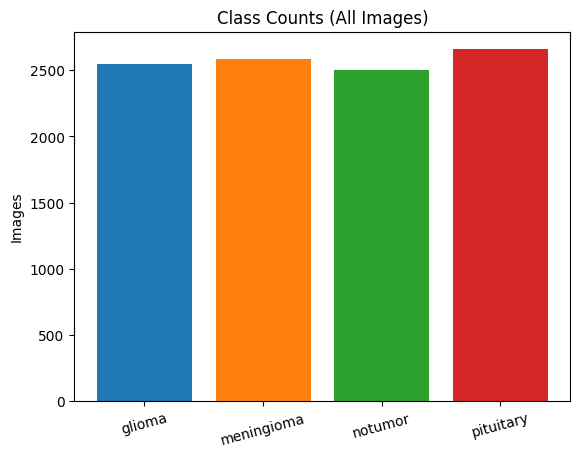

In [ ]:
#cell 15 to normalize the images
# A) Simple class count (uses full Y)
import numpy as np, matplotlib.pyplot as plt
from collections import Counter

inv_classes = {v:k for k,v in classes.items()}   # classes already defined
counts = Counter(Y)
names = [inv_classes[i] for i in sorted(counts.keys())]
vals  = [counts[i] for i in sorted(counts.keys())]

plt.bar(names, vals, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
plt.title("Class Counts (All Images)")
plt.ylabel("Images")
plt.xticks(rotation=15)
plt.show()

In [ ]:
#cell 16 to split the data into train and test sets
# B) OPTIONAL train/test split distribution (run ONLY after creating xtrain, xtest, ytrain, ytest)
try:
    ytrain, ytest  # just to check
    import matplotlib.pyplot as plt
    def bar_dist(y, title):
        c = Counter(y)
        ordered_ids = sorted(c.keys())
        plt.bar([inv_classes[i] for i in ordered_ids],
                [c[i] for i in ordered_ids])
        plt.title(title); plt.xticks(rotation=15)
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); bar_dist(ytrain, "Train")
    plt.subplot(1,2,2); bar_dist(ytest, "Test")
    plt.tight_layout(); plt.show()
except NameError:
    print("Run train_test_split first to create ytrain / ytest.")

Run train_test_split first to create ytrain / ytest.


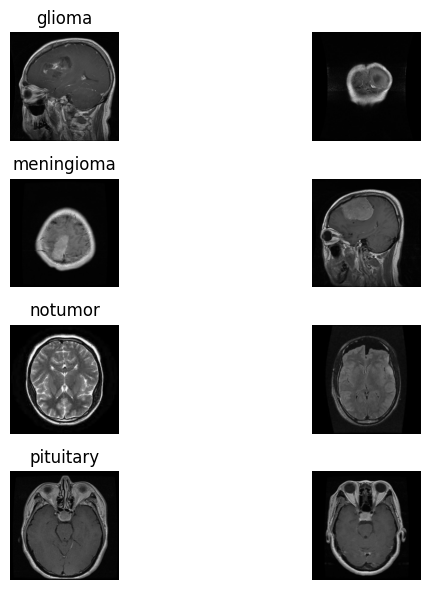

In [ ]:
# cell 17 to visualize some samples from the dataset
# C) Show 2 random samples per class
import random, matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
for ci in sorted(inv_classes.keys()):
    idxs = np.where(Y==ci)[0]
    for k in range(2):
        idx = random.choice(idxs)
        plt_idx = ci*2 + k + 1
        plt.subplot(4,2,plt_idx)
        plt.imshow(X[idx][:,:,::-1])  # BGR->RGB
        plt.axis('off')
        if k==0: plt.title(inv_classes[ci])
plt.tight_layout(); plt.show()

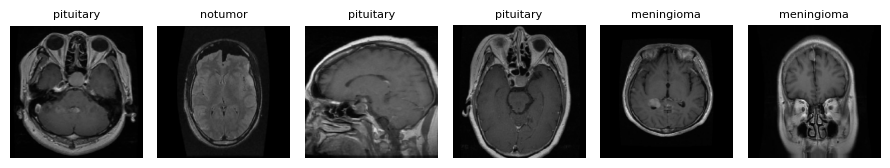

In [ ]:
# cell 18 to visualize some samples from the dataset
# D) Quick augmentation preview (needs train_data generator already made)
batch_imgs, batch_labels = next(train_data)
# Invert mobilenet preprocess: x = (x/127.5)-1  => original ≈ (x+1)*127.5
show_imgs = ((batch_imgs + 1)*127.5).clip(0,255).astype('uint8')
plt.figure(figsize=(9,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(show_imgs[i])
    plt.axis('off')
    plt.title(inv_classes[np.argmax(batch_labels[i])], fontsize=8)
plt.tight_layout(); plt.show()

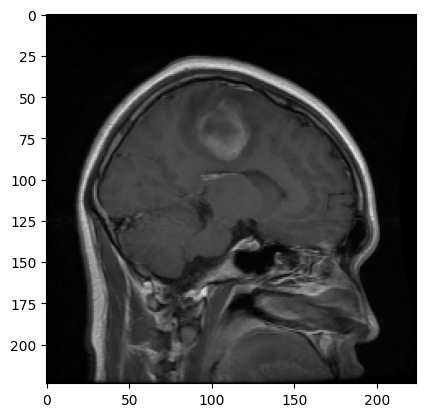

In [ ]:
#cell 19 to visualize one image from the dataset
plt.imshow(X[0], cmap='gray')

In [ ]:
#cell 20 to check the shape of one image
X[0].shape

(224, 224, 3)

In [ ]:
#cell 21 to split the data into train and test sets
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, random_state=10,test_size=.20) #random_state=10

In [ ]:
# cell 22 to check the shape of train and test sets
xtrain.shape, xtest.shape

((8229, 224, 224, 3), (2058, 224, 224, 3))

In [ ]:
#cell 23 to check the shape of train and test sets
#Model building starts
from tensorflow.keras.models import Model, Sequential
import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input,Bidirectional,LSTM,Lambda, GRU
from tensorflow.keras.layers import Permute,GlobalMaxPool1D,Concatenate, Dense, BatchNormalization, Dropout, GlobalAveragePooling1D, GlobalAveragePooling2D,Add
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Activation, Flatten,MaxPooling1D,Conv1D, Conv2D,MaxPool2D,MaxPooling2D

In [ ]:
# cell 24 to build the model
model = Sequential()


model.add(Conv2D(32, 5, activation='relu',input_shape = (224,224,3))) #3 Conv1D
model.add(MaxPooling2D(pool_size=4)) #2
model.add(BatchNormalization())
model.add(Dropout(0.1))


model.add(Conv2D(64, 5, activation='relu'))
model.add(Conv2D(64, 5, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(128, 5, activation='relu')) #2
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(256, 5, activation='relu')) #2
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.1))


model.add(Flatten())
model.add(Dense(256, activation='relu')) #128
model.add(BatchNormalization())
model.add(Dropout(0.1)) #0.3
model.add(Dense(4, activation='softmax'))  # ✅ FIXED: 4 classes for brain tumor classification


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 51, 51, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,446,916 (5.52 MB)

 Trainable params: 1,445,444 (5.51 MB)

 Non-trainable params: 1,472 (5.75 KB)

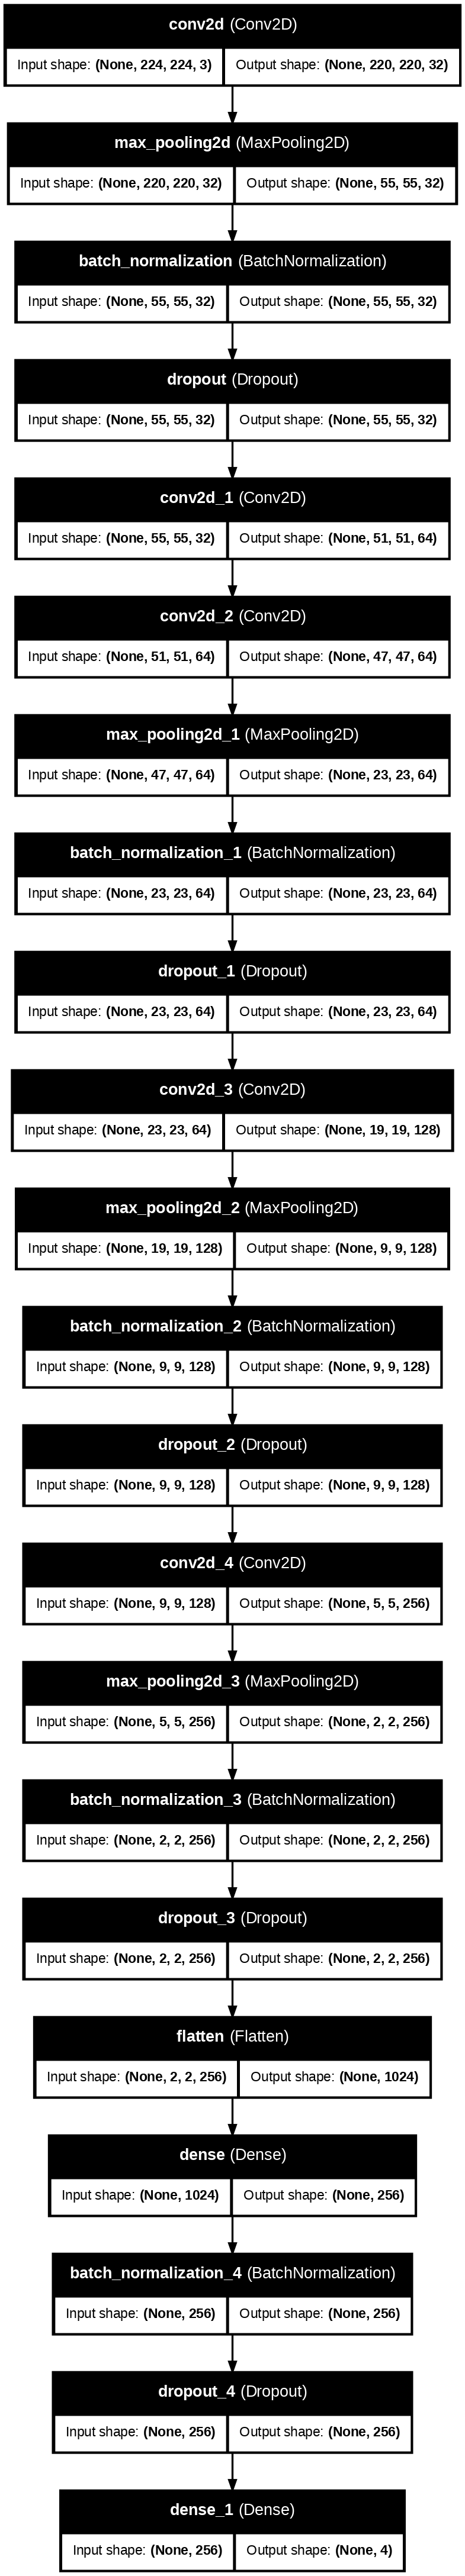

✅ Saved PNG: /content/model_vis/cnn_architecture.png


In [ ]:
#cell 25 to visualize model architecture

import os, pathlib, subprocess, tempfile
from IPython.display import Image, SVG
from tensorflow.keras.utils import plot_model, model_to_dot

def has_dot():
    try:
        subprocess.run(["dot","-V"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except Exception:
        return False

# Use relative path for output
out_dir = PROJECT_ROOT / "model_vis"
try:
    out_dir.mkdir(exist_ok=True)
except Exception:
    out_dir = pathlib.Path(tempfile.mkdtemp(prefix="model_vis_"))
    print(f"⚠️ Using temp dir: {out_dir}")

model.summary()

if has_dot():
    png_path = out_dir / "cnn_architecture.png"
    plot_model(model, to_file=str(png_path), show_shapes=True, show_layer_names=True, dpi=120)
    display(Image(filename=str(png_path)))
    print(f"✅ Saved PNG: {png_path}")
else:
    try:
        svg = model_to_dot(model, show_shapes=True, show_layer_names=True).create(prog='dot', format='svg')
        display(SVG(svg))
        print("✅ Displayed SVG (Graphviz python binding only).")
    except Exception as e:
        print("⚠️ Graph rendering failed, ASCII fallback.\nReason:", e)
        for i,l in enumerate(model.layers):
            try:
                print(f"{i:02d} {l.name:25s} {l.output_shape} params={l.count_params()}")
            except:
                pass


In [ ]:

 model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 51, 51, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,446,916 (5.52 MB)

 Trainable params: 1,445,444 (5.51 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
# cell 26 to compile the model
model.compile(optimizer='Adam',
            loss='sparse_categorical_crossentropy',
             metrics=["accuracy"])

In [ ]:
# cell 27 to train the model with callbacks

# Setup callbacks for better training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Create models directory
models_dir = PROJECT_ROOT / "saved_models"
models_dir.mkdir(exist_ok=True)

# Callbacks
callbacks = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=str(models_dir / 'brain_tumor_best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    # Stop training if no improvement for 10 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate if validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Starting training with callbacks...")
print(f"✅ Best model will be saved to: {models_dir / 'brain_tumor_best_model.h5'}")

r = model.fit(
    xtrain,
    ytrain,
    epochs=60,
    batch_size=32,
    verbose=1,
    validation_data=(xtest, ytest),
    shuffle=True,  # ✅ Changed to True for better training
    callbacks=callbacks  # ✅ Added callbacks
)

print("\n✅ Training completed!")


✅ Starting training with callbacks...
✅ Best model will be saved to: /content/saved_models/brain_tumor_best_model.h5
Epoch 1/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6993 - loss: 0.8375
Epoch 1: val_accuracy improved from -inf to 0.84985, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.6996 - loss: 0.8367 - val_accuracy: 0.8499 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 2/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8789 - loss: 0.3436
Epoch 2: val_accuracy did not improve from 0.84985
258/258 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.8789 - loss: 0.3434 - val_accuracy: 0.7468 - val_loss: 0.7105 - learning_rate: 0.0010
Epoch 3/60
256/258 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9106 - loss: 0.2539
Epoch 3: val_accuracy improved from 0.84985 to 0.88921, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9108 - loss: 0.2534 - val_accuracy: 0.8892 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 4/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9316 - loss: 0.1922
Epoch 4: val_accuracy did not improve from 0.88921
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9317 - loss: 0.1920 - val_accuracy: 0.7949 - val_loss: 0.7599 - learning_rate: 0.0010
Epoch 5/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9496 - loss: 0.1300
Epoch 5: val_accuracy improved from 0.88921 to 0.95773, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9496 - loss: 0.1299 - val_accuracy: 0.9577 - val_loss: 0.1366 - learning_rate: 0.0010
Epoch 6/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9735 - loss: 0.0744
Epoch 6: val_accuracy did not improve from 0.95773
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9735 - loss: 0.0744 - val_accuracy: 0.8897 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 7/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9707 - loss: 0.0959
Epoch 7: val_accuracy did not improve from 0.95773
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9707 - loss: 0.0958 - val_accuracy: 0.9383 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 8/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9839 - loss: 0.0557
Epoch 8: val_accuracy improved from 0.95773 to 0.97036, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9839 - loss: 0.0557 - val_accuracy: 0.9704 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 9/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9877 - loss: 0.0393
Epoch 9: val_accuracy did not improve from 0.97036
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9876 - loss: 0.0393 - val_accuracy: 0.8654 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 10/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9752 - loss: 0.0713
Epoch 10: val_accuracy did not improve from 0.97036
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9752 - loss: 0.0713 - val_accuracy: 0.9689 - val_loss: 0.1075 - learning_rate: 0.0010
Epoch 11/60
256/258 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9866 - loss: 0.0373
Epoch 11: val_accuracy did not improve from 0.97036
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9866 - loss: 0.0374 - val_accuracy: 0.9436 - val_loss: 0.1897 - learning_rate: 0.0010
Epoch 12/6

258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9869 - loss: 0.0346 - val_accuracy: 0.9747 - val_loss: 0.1232 - learning_rate: 0.0010
Epoch 13/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9888 - loss: 0.0365
Epoch 13: val_accuracy did not improve from 0.97473

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9888 - loss: 0.0364 - val_accuracy: 0.9694 - val_loss: 0.1182 - learning_rate: 0.0010
Epoch 14/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9825 - loss: 0.0596
Epoch 14: val_accuracy improved from 0.97473 to 0.98445, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9826 - loss: 0.0594 - val_accuracy: 0.9845 - val_loss: 0.0823 - learning_rate: 5.0000e-04
Epoch 15/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9975 - loss: 0.0080
Epoch 15: val_accuracy improved from 0.98445 to 0.98785, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9975 - loss: 0.0080 - val_accuracy: 0.9879 - val_loss: 0.0756 - learning_rate: 5.0000e-04
Epoch 16/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9922 - loss: 0.0259
Epoch 16: val_accuracy improved from 0.98785 to 0.98882, saving model to /content/saved_models/brain_tumor_best_model.h5


258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9922 - loss: 0.0258 - val_accuracy: 0.9888 - val_loss: 0.0705 - learning_rate: 5.0000e-04
Epoch 17/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9980 - loss: 0.0061
Epoch 17: val_accuracy did not improve from 0.98882
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9796 - val_loss: 0.0983 - learning_rate: 5.0000e-04
Epoch 18/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9947 - loss: 0.0177
Epoch 18: val_accuracy did not improve from 0.98882
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9947 - loss: 0.0177 - val_accuracy: 0.9820 - val_loss: 0.0872 - learning_rate: 5.0000e-04
Epoch 19/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9959 - loss: 0.0110
Epoch 19: val_accuracy did not improve from 0.98882
258/258 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9959 - loss: 0.0110 - val_accuracy: 0.9864 - val_loss: 0.0662 - learning_rate: 5.0

258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9898 - val_loss: 0.0744 - learning_rate: 2.5000e-04
Epoch 27/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9996 - loss: 0.0022
Epoch 27: val_accuracy did not improve from 0.98980
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9893 - val_loss: 0.0720 - learning_rate: 2.5000e-04
Epoch 28/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 28: val_accuracy did not improve from 0.98980
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9898 - val_loss: 0.0681 - learning_rate: 2.5000e-04
Epoch 29/60
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9989 - loss: 0.0069
Epoch 29: val_accuracy did not improve from 0.98980

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9989

In [ ]:
 # cell 28 to plot the loss and accuracy curves
 def plot_loss_curves_mplt(history,

                          fill_a=0,
                          with_best_point=False,
                          plt_style="seaborn-v0_8-whitegrid",
                          start_epoch=1,
                          figsize = (20, 8)
                          ):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]


    accuracy = history.history["accuracy"]

    val_accuracy = history.history["val_accuracy"]


    epochs = range(start_epoch, len(history.history["loss"])+1)

    index_loss = np.argmin(val_loss)  # This is the epoch with the lowest validation loss
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_accuracy)
    acc_highest = val_accuracy[index_acc]

    sc_label = 'Best epoch = ' + str(index_loss + start_epoch)
    vc_label = 'Best epoch = ' + str(index_acc + start_epoch)

    plt.figure(figsize=figsize, facecolor='white')
    plt.style.use(plt_style)

    # Plot loss
    plt.subplot(1, 2, 1)
    ax1 = plt.gca()  # Get the current axis
    ax1.plot(epochs, loss, '#008000', label='Training loss', linewidth=4)
    ax1.plot(epochs, val_loss,  "#FE0000", label='Validation loss', linewidth=4)
    if fill_a:
        ax1.fill_between(epochs, val_loss, loss, color='gray', alpha=fill_a)
    ax1.set_title("Training and Validation Loss", fontsize=20)
    ax1.set_xlabel("Epochs", fontsize=20)
    ax1.set_ylabel("Loss", fontsize=20)
    ax1.set_xlim([0.5, len(epochs)])
    # Plot best point
    if with_best_point:
        ax1.scatter(index_loss + start_epoch, val_lowest, s=150, c='blue', label=sc_label)
    ax1.legend(fontsize=18, loc='upper right', frameon=False)

    # Plot accuracy
    plt.subplot(1, 2, 2)
    ax2 = plt.gca()  # Get the current axis
    ax2.plot(epochs, accuracy, '#008000',  label='Training Accuracy', linewidth=4)
    ax2.plot(epochs, val_accuracy,"#FE0000", label='Validation Accuracy', linewidth=4)
    if fill_a:
        ax2.fill_between(epochs, val_accuracy, accuracy, color='gray', alpha=fill_a)
    ax2.set_title("Training and Validation Accuracy", fontsize=20)
    ax2.set_xlabel("Epochs", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_xlim([0.5, len(epochs)])
    ax2.set_ylim([0, 1.1])
    # Plot best point
    if with_best_point:
        ax2.scatter(index_acc + start_epoch, acc_highest, s=150, c='blue', label=vc_label)
    ax2.legend(fontsize=18, loc='lower right', frameon=False)

    plt.tight_layout()
    plt.show()

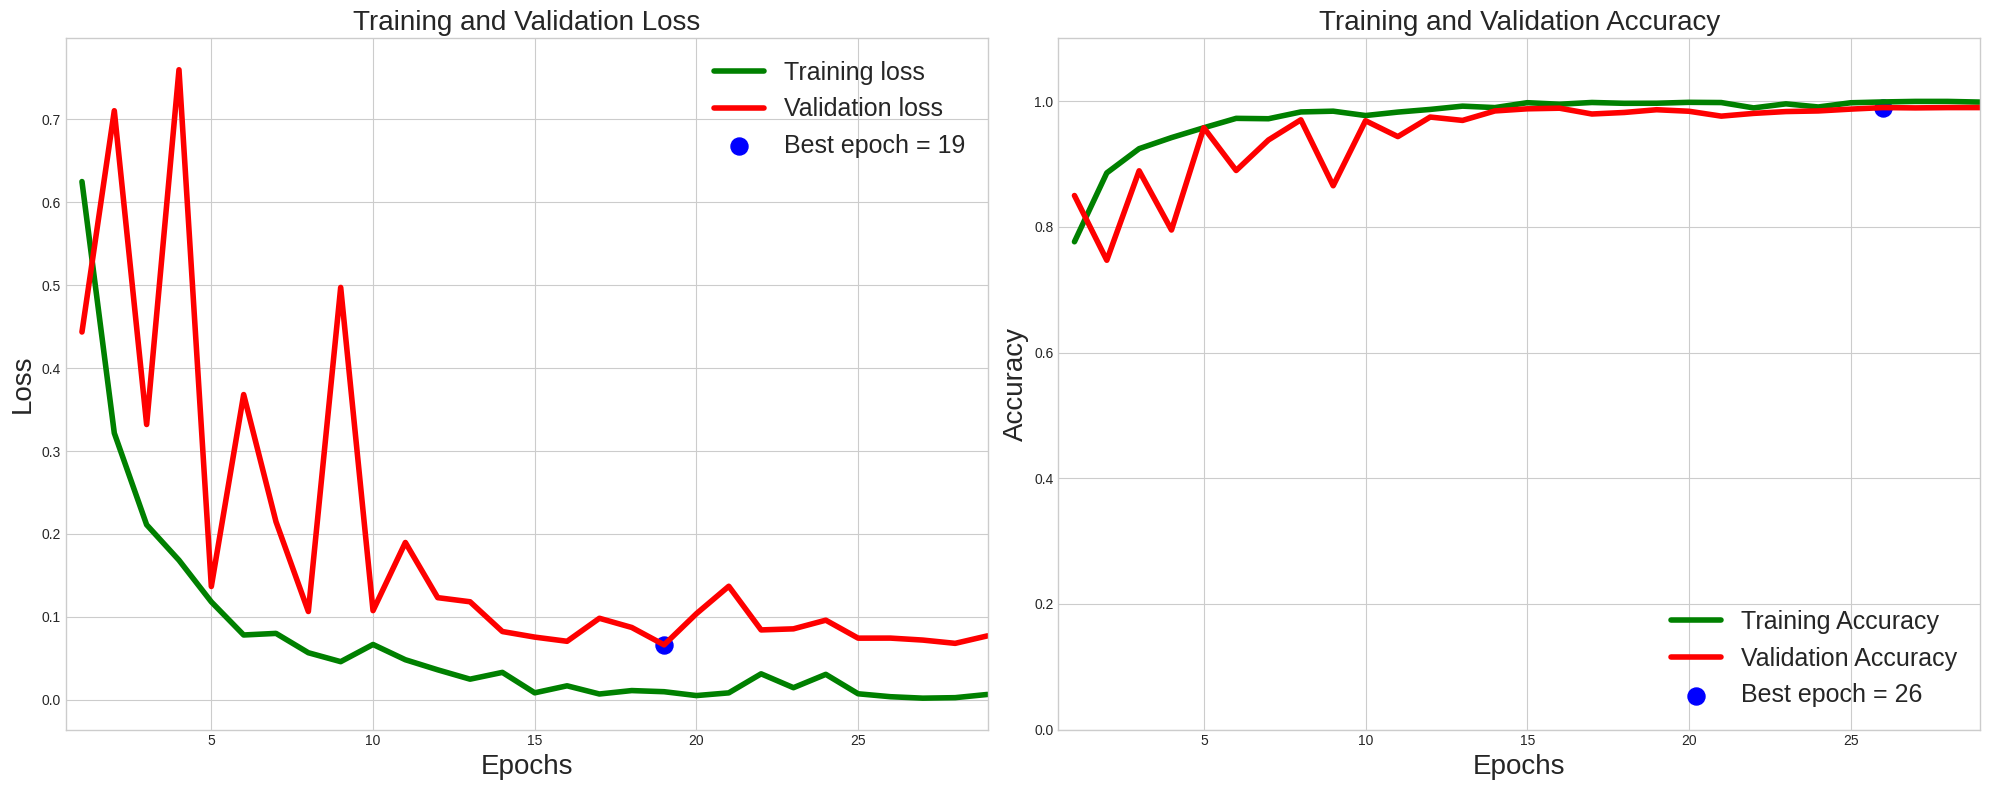

In [ ]:
# cell 29 to plot the loss and accuracy curves
plot_loss_curves_mplt(r, with_best_point=True)

In [ ]:
# cell 30 to make predictions
pred=model.predict(xtest)
Y_pred = np.argmax(pred, 1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [ ]:
# cell 31 to check the shape of predictions
Y_pred.shape


(2058,)

In [ ]:
# cell 32 to check the shape of actual test labels
ytest.shape

(2058,)

In [ ]:
# cell 33 to evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
print('Confusion Matrix')
print(confusion_matrix(ytest, Y_pred))

Confusion Matrix
[[522   9   4   0]
 [  8 491   0   6]
 [  0   0 532   0]
 [  1   0   0 485]]


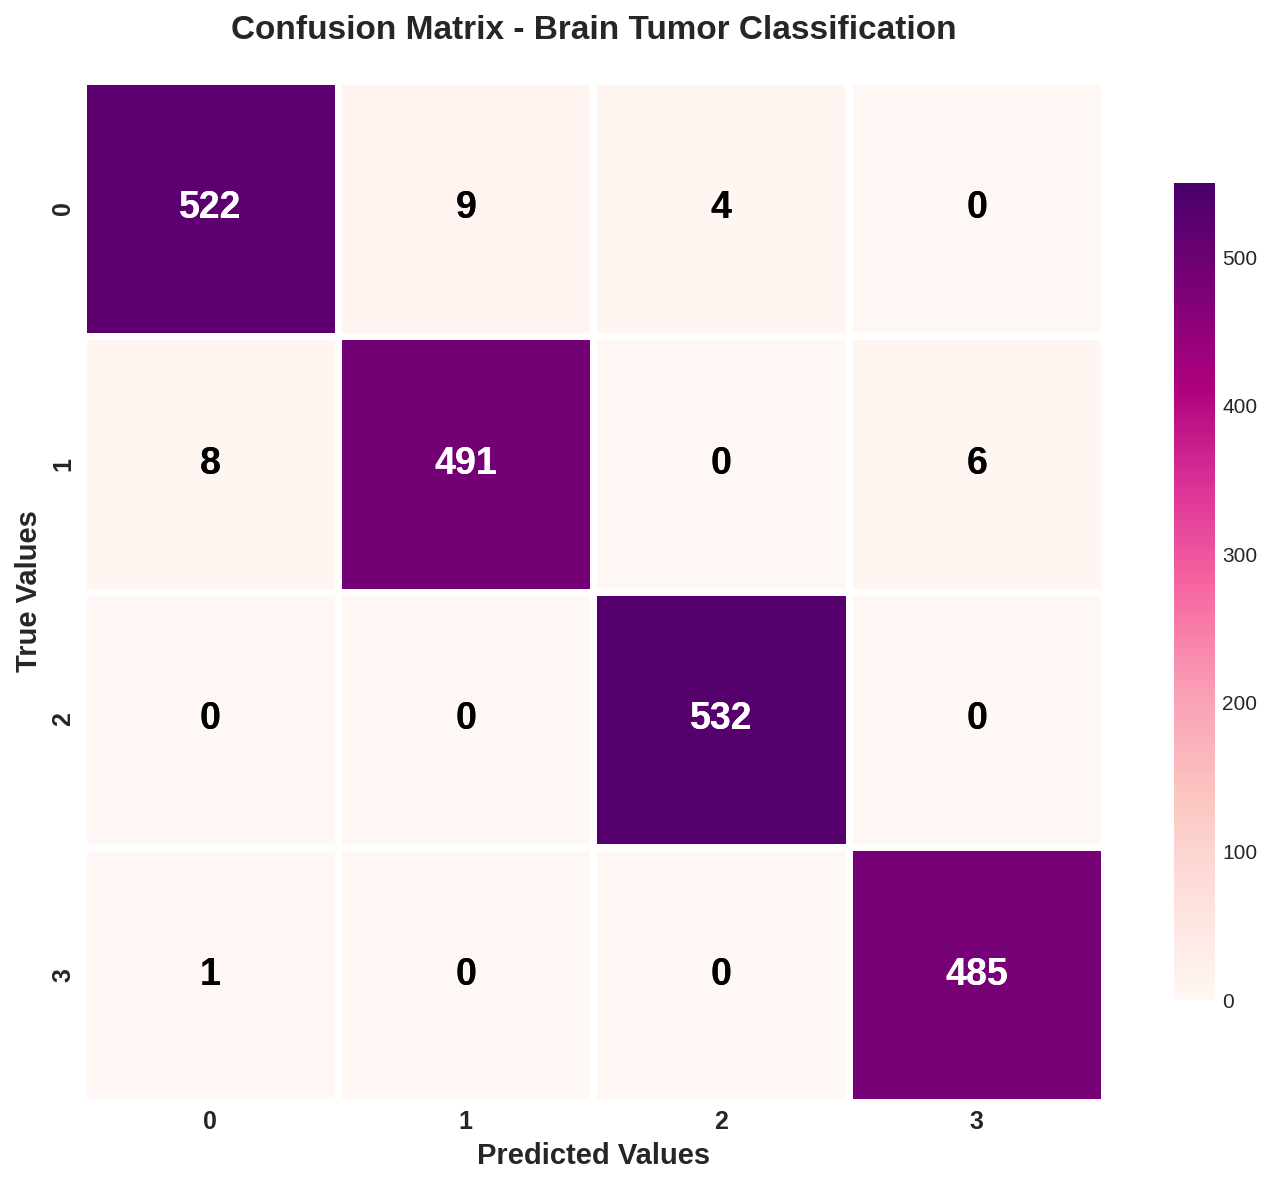

In [ ]:
# cell 34 to print classification report
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(ytest, Y_pred)
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap with dark background colors for better contrast
sns.heatmap(cm, square=True, annot=True, fmt="d", cbar=True,
            cmap='RdPu',  # Red-Purple theme - better contrast
            annot_kws={"size": 18, "weight": "bold"},
            linewidths=2.5, linecolor='white',
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=550)  # Set consistent scale

# Manually add white text on dark cells for perfect visibility
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        # Use white text for values > 100, black for smaller values
        text_color = 'white' if value > 100 else 'black'
        plt.text(j + 0.5, i + 0.5, str(value),
                ha='center', va='center',
                fontsize=18, weight='bold', color=text_color)

plt.xlabel('Predicted Values', fontsize=14, weight='bold')
plt.ylabel('True Values', fontsize=14, weight='bold')
plt.title('Confusion Matrix - Brain Tumor Classification', fontsize=16, weight='bold', pad=20)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# cell 35 to print classification report
print('Classification Report')
target_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
print(classification_report(ytest, Y_pred, target_names=target_names))


Classification Report
                  precision    recall  f1-score   support

    glioma_tumor       0.98      0.98      0.98       535
meningioma_tumor       0.98      0.97      0.98       505
        no_tumor       0.99      1.00      1.00       532
 pituitary_tumor       0.99      1.00      0.99       486

        accuracy                           0.99      2058
       macro avg       0.99      0.99      0.99      2058
    weighted avg       0.99      0.99      0.99      2058



In [ ]:
print(ytrain)

[2 1 3 ... 0 3 0]


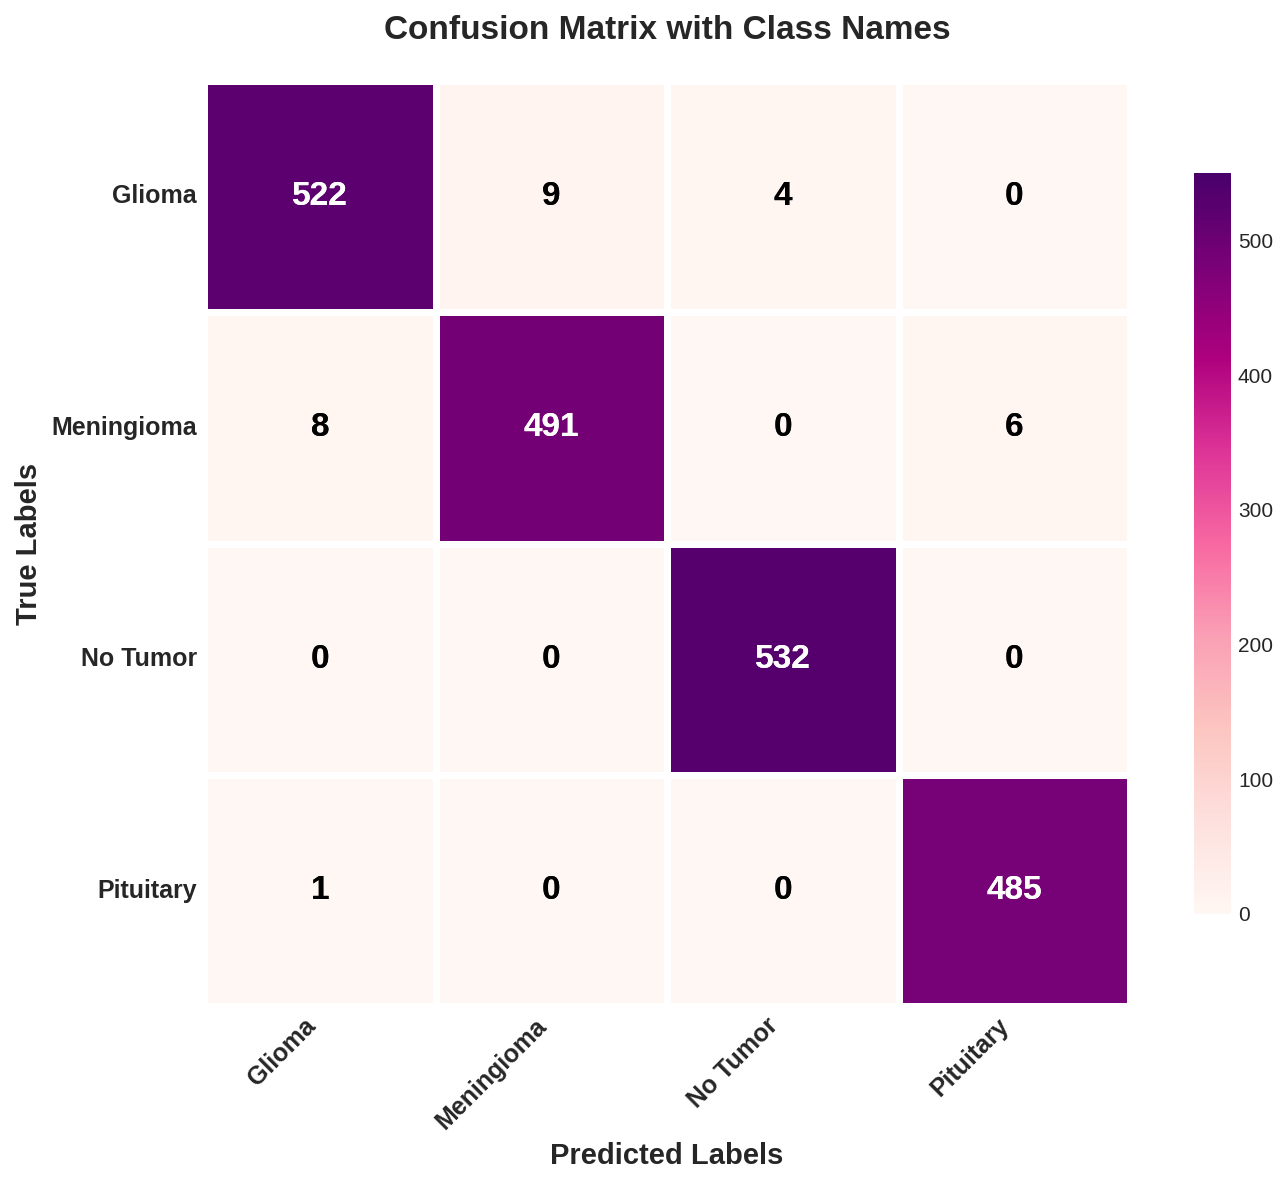

In [ ]:
# cell 36 to plot confusion matrix with labels
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with proper size
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap with RdPu theme matching Cell 34
sns.heatmap(cm, square=True, annot=True, fmt="d", cbar=True,
            cmap='RdPu',
            annot_kws={"size": 16, "weight": "bold"},
            linewidths=2.5, linecolor='white',
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=550)

# Add adaptive text colors for better visibility
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        text_color = 'white' if value > 100 else 'black'
        plt.text(j + 0.5, i + 0.5, str(value),
                ha='center', va='center',
                fontsize=16, weight='bold', color=text_color)

# Set class name labels on axes
plt.xlabel('Predicted Labels', fontsize=14, weight='bold')
plt.ylabel('True Labels', fontsize=14, weight='bold')
plt.title('Confusion Matrix with Class Names', fontsize=16, weight='bold', pad=20)

# Apply class names to tick labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5],
           labels=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'],
           fontsize=12, weight='bold', rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5],
           labels=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'],
           fontsize=12, weight='bold', rotation=0)

plt.tight_layout()
plt.show()

Confusion Matrix :
[[522   9   4   0]
 [  8 491   0   6]
 [  0   0 532   0]
 [  1   0   0 485]]

Accuracy Score : 0.9863945578231292

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       535
           1       0.98      0.97      0.98       505
           2       0.99      1.00      1.00       532
           3       0.99      1.00      0.99       486

    accuracy                           0.99      2058
   macro avg       0.99      0.99      0.99      2058
weighted avg       0.99      0.99      0.99      2058



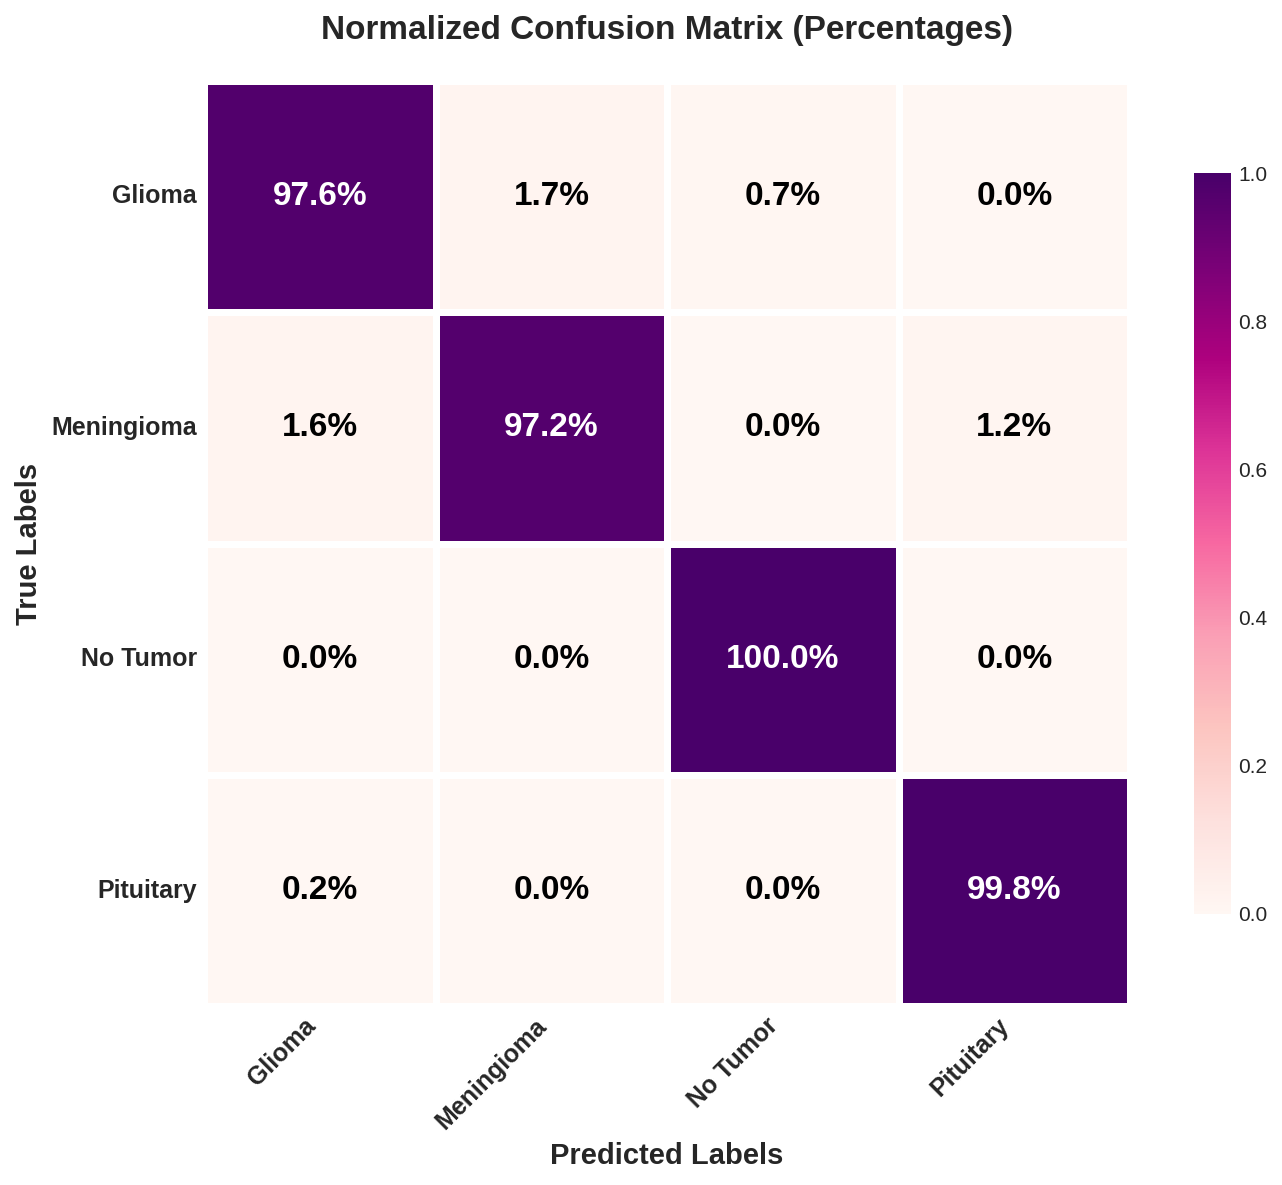

In [ ]:
# cell 37 to plot normalized confusion matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

results = confusion_matrix(ytest, Y_pred)

# Print text summary
print('Confusion Matrix :')
print(results)
print('\nAccuracy Score :', accuracy_score(ytest, Y_pred))
print('\nClassification Report :')
print(classification_report(ytest, Y_pred))

# Create normalized confusion matrix (percentages)
results_normalized = results.astype('float') / results.sum(axis=1)[:, np.newaxis]

# Create figure with proper size
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap with RdPu theme - annot=False to avoid duplication
sns.heatmap(results_normalized, square=True, annot=False, fmt='.1%',
            cbar=True, cmap='RdPu',
            linewidths=2.5, linecolor='white',
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1.0)

# Manually add text with adaptive colors (only once!)
for i in range(results_normalized.shape[0]):
    for j in range(results_normalized.shape[1]):
        value = results_normalized[i, j]
        text = f'{value:.1%}'
        text_color = 'white' if value > 0.5 else 'black'
        plt.text(j + 0.5, i + 0.5, text,
                ha='center', va='center',
                fontsize=16, weight='bold', color=text_color)

# Set labels
plt.xlabel('Predicted Labels', fontsize=14, weight='bold')
plt.ylabel('True Labels', fontsize=14, weight='bold')
plt.title('Normalized Confusion Matrix (Percentages)', fontsize=16, weight='bold', pad=20)

# Apply class names to tick labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5],
           labels=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'],
           fontsize=12, weight='bold', rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5],
           labels=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'],
           fontsize=12, weight='bold', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# cell 38 to compute ROC AUC for multi-class classification
import numpy as np
from sklearn import metrics
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(ytest, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# Get prediction probabilities
y_score = model.predict(xtest)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = metrics.roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = metrics.roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = metrics.auc(fpr["micro"], tpr["micro"])

print("ROC AUC Scores:")
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
print(f"Micro-average: {roc_auc['micro']:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
ROC AUC Scores:
Glioma: 0.9951
Meningioma: 0.9987
No Tumor: 0.9999
Pituitary: 0.9998
Micro-average: 0.9988


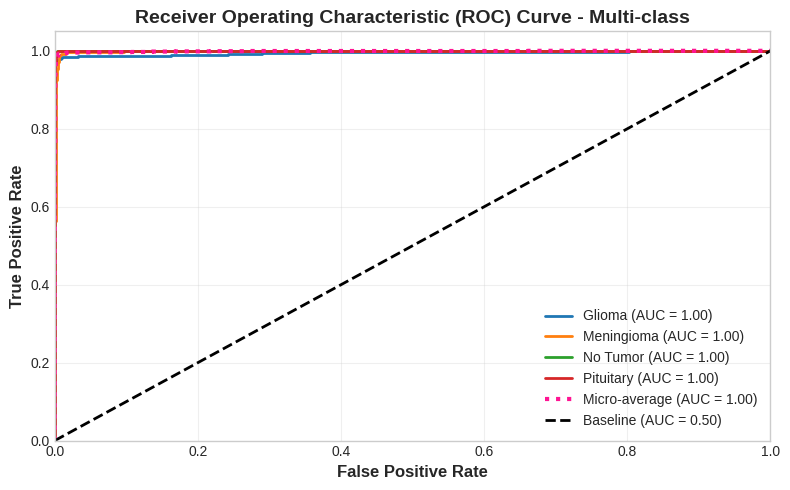

In [ ]:
# cell 39 to plot ROC AUC curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Plot ROC curve for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

for i, color in zip(range(n_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
ax.plot(fpr["micro"], tpr["micro"],
        label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
        color='deeppink', linestyle=':', linewidth=3)

# Plot baseline (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Baseline (AUC = 0.50)')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Receiver Operating Characteristic (ROC) Curve - Multi-class', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

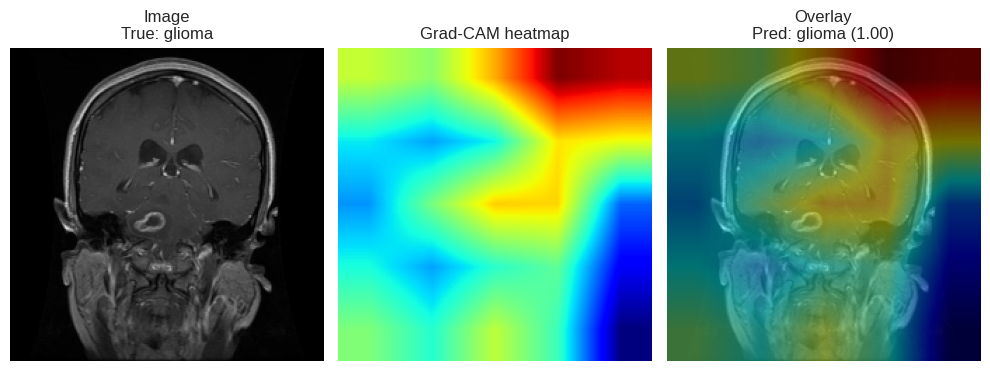

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def get_last_conv_layer_name(m):
    for layer in reversed(m.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

def gradcam_heatmap_bgr(img_bgr, model, layer_name=None, class_index=None):
    """
    img_bgr: HxWx3 BGR uint8/float32 (same scale as training)
    returns: heatmap (HxW, 0..1), probs (model softmax output)
    """
    if layer_name is None:
        layer_name = get_last_conv_layer_name(model)

    x = img_bgr.astype(np.float32)  # keep original magnitude (no /255)
    x = np.expand_dims(x, axis=0)  # Add batch dimension

    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
        tape.watch(input_tensor)

        # Manually perform forward pass through the model's layers
        # to get the intermediate conv_out and the final predictions.
        current_output = input_tensor
        conv_out = None

        for layer in model.layers:
            # Ensure training=False is passed for layers like BatchNormalization and Dropout
            current_output = layer(current_output, training=False)
            if layer.name == layer_name:
                conv_out = current_output
                tape.watch(conv_out) # Watch conv_out right after its computation

        preds = current_output # current_output now holds the final predictions

        if class_index is None:
            class_index = tf.argmax(preds[0])
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    # Check if grads is None and handle if necessary (though this fix aims to prevent it)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}. This indicates a problem in the gradient computation path.")

    weights = tf.reduce_mean(grads, axis=(0, 1, 2))  # GAP over H,W

    cam = tf.tensordot(conv_out[0], weights, axes=[[2], [0]])
    cam = tf.maximum(cam, 0)  # ReLU
    cam = cam.numpy()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img_bgr.shape[1], img_bgr.shape[0]), interpolation=cv2.INTER_LINEAR)
    return cam, preds.numpy()[0]

def overlay_gradcam_bgr(img_bgr, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    hm = np.uint8(255 * np.clip(heatmap, 0, 1))
    hm_color = cv2.applyColorMap(hm, colormap)  # BGR
    base = img_bgr.astype(np.float32) / 255.0
    hm_f = hm_color.astype(np.float32) / 255.0
    overlay = (1 - alpha) * base + alpha * hm_f
    overlay = np.clip(overlay * 255.0, 0, 255).astype(np.uint8)
    # Convert to RGB for matplotlib display
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# ---- Demo on a test sample ----
test_idx = 0  # change to inspect other images
img_bgr = xtest[test_idx]  # model was trained on BGR from cv2

last_conv = get_last_conv_layer_name(model)
heatmap, probs = gradcam_heatmap_bgr(img_bgr, model, layer_name=last_conv, class_index=None)
overlay_rgb = overlay_gradcam_bgr(img_bgr, heatmap, alpha=0.45)

pred_id = int(np.argmax(probs))
true_id = int(ytest[test_idx])

# Try to use your existing inv_classes mapping if available
try:
    pred_name = inv_classes[pred_id]
    true_name = inv_classes[true_id]
except Exception:
    pred_name = str(pred_id)
    true_name = str(true_id)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Image\nTrue: {true_name}")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay_rgb)
plt.title(f"Overlay\nPred: {pred_name} ({probs[pred_id]:.2f})")
plt.axis('off')

plt.tight_layout()
plt.show()

Conv layers: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']


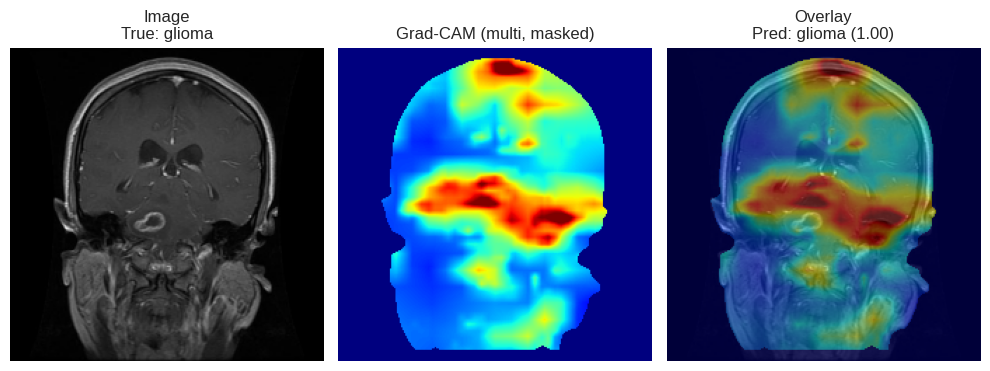

In [ ]:
# cell 41 - Multi-layer Grad-CAM with brain mask and robust normalization

import numpy as np, tensorflow as tf, cv2, matplotlib.pyplot as plt

# 1) List conv layers (so you can pick higher-res ones)
def list_conv_layers(m):
    return [l.name for l in m.layers if isinstance(l, tf.keras.layers.Conv2D)]

# 2) Simple brain mask on BGR images (Otsu + morphology)
def brain_mask_bgr(img_bgr):
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    g = cv2.GaussianBlur(g, (7,7), 0)
    _, th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k, iterations=2)
    cnts,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    m = np.zeros_like(th, dtype=np.uint8)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        cv2.drawContours(m, [c], -1, 255, -1)
    return (m > 0).astype(np.uint8)

# 3) Grad-CAM for a single conv layer (no extra preprocessing; matches training)
def gradcam_for_layer(img_bgr, model, layer_name, class_index=None):
    x = img_bgr.astype(np.float32)
    x = np.expand_dims(x, 0)

    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
        tape.watch(input_tensor)

        current_output = input_tensor
        conv_out = None

        for layer in model.layers:
            current_output = layer(current_output, training=False)
            if layer.name == layer_name:
                conv_out = current_output
                tape.watch(conv_out)
        preds = current_output

        if class_index is None:
            class_index = tf.argmax(preds[0])
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}. This indicates a problem in the gradient computation path.")

    weights = tf.reduce_mean(grads, axis=(0,1,2))
    cam = tf.tensordot(conv_out[0], weights, axes=[[2],[0]])
    cam = tf.maximum(cam, 0).numpy()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img_bgr.shape[1], img_bgr.shape[0]), interpolation=cv2.INTER_LINEAR)
    return cam, preds.numpy()[0]

# 4) Robust normalization inside brain mask + border trim
def normalize_inside_mask(hm, mask, percentile=99, border_trim=8):
    h = hm.copy().astype(np.float32)
    if mask is not None and mask.any():
        vals = h[mask > 0]
        if vals.size > 0:
            hi = np.percentile(vals, percentile)
            if hi > 0: h = np.clip(h / hi, 0, 1)
    else:
        hi = np.percentile(h, percentile)
        if hi > 0: h = np.clip(h / hi, 0, 1)
    if border_trim > 0:
        h[:border_trim,:] = 0; h[-border_trim:,:] = 0
        h[:,:border_trim] = 0; h[:,-border_trim:] = 0
    if h.max() > 0:
        h = (h - h.min()) / (h.max() - h.min() + 1e-8)
    return h

# 5) Multi-layer Grad-CAM blend
def multilayer_gradcam(img_bgr, model, layers=None, class_index=None,
                       use_mask=True, percentile=99, border_trim=8):
    if layers is None:
        convs = list_conv_layers(model)
        layers = convs[-3:] if len(convs) >= 3 else convs  # last 2-3 convs
    maps = []
    probs_ref = None
    for ln in layers:
        hm, probs = gradcam_for_layer(img_bgr, model, ln, class_index)
        maps.append(hm)
        probs_ref = probs
    # Slightly favor earlier (higher-res) convs
    ws = np.linspace(1.0, 0.7, num=len(maps)).astype(np.float32)
    ws /= ws.sum()
    combo = np.zeros_like(maps[0], dtype=np.float32)
    for w, m in zip(ws, maps): combo += w * m
    mask = brain_mask_bgr(img_bgr) if use_mask else None
    if mask is not None: combo *= mask
    combo = normalize_inside_mask(combo, mask, percentile=percentile, border_trim=border_trim)
    return combo, probs_ref

# 6) Overlay utility (BGR in, RGB out for plt)
def overlay_bgr(img_bgr, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    hm = np.uint8(255 * np.clip(heatmap, 0, 1))
    hm_color = cv2.applyColorMap(hm, colormap)  # BGR
    base = img_bgr.astype(np.float32) / 255.0
    ov = np.clip((1 - alpha) * base + alpha * (hm_color.astype(np.float32)/255.0), 0, 1)
    return cv2.cvtColor((ov * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)

# ---- Example usage on a few samples ----
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # adjust if needed

def show_xai(sample_idx=0, layers=None, use_mask=True):
    img = xtest[sample_idx]
    heat, probs = multilayer_gradcam(img, model, layers=layers, class_index=None,
                                     use_mask=use_mask, percentile=99, border_trim=8)
    ov = overlay_bgr(img, heat, alpha=0.45)
    pred_id = int(np.argmax(probs)); true_id = int(ytest[sample_idx])
    pred_name = class_names[pred_id] if pred_id < len(class_names) else str(pred_id)
    true_name = class_names[true_id] if true_id < len(class_names) else str(true_id)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(f"Image\nTrue: {true_name}"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(heat, cmap='jet'); plt.title("Grad-CAM (multi, masked)"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(ov); plt.title(f"Overlay\nPred: {pred_name} ({probs[pred_id]:.2f})"); plt.axis('off')
    plt.tight_layout(); plt.show()

# Pick indices to inspect
print("Conv layers:", list_conv_layers(model))
show_xai(sample_idx=0, layers=None, use_mask=True)
# Try other samples:
# for i in [1,2,3]: show_xai(sample_idx=i)


In [ ]:
# cell 42 - Grad-CAM++ core (returns heatmap 0..1 and softmax probs)

import numpy as np, tensorflow as tf, cv2

def get_last_conv_layer_name(m):
    for layer in reversed(m.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

def gradcampp_heatmap_bgr(img_bgr, model, layer_name=None, class_index=None):
    """
    Grad-CAM++ (Chattopadhyay et al.)
    img_bgr: HxWx3 BGR in the same scale as training (here 0..255)
    returns: (heatmap 0..1, probs vector)
    """
    if layer_name is None:
        layer_name = get_last_conv_layer_name(model)

    x = img_bgr.astype(np.float32)[None, ...]

    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
        tape.watch(input_tensor)

        current_output = input_tensor
        conv_out = None

        for layer in model.layers:
            current_output = layer(current_output, training=False)
            if layer.name == layer_name:
                conv_out = current_output
                tape.watch(conv_out)  # Watch conv_out right after its computation
        preds = current_output  # current_output now holds the final predictions

        if class_index is None:
            class_index = tf.cast(tf.argmax(preds[0]), tf.int32)
        score = preds[:, class_index]

    grads  = tape.gradient(score, conv_out)
    # Check if grads is None and handle if necessary
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}. This indicates a problem in the gradient computation path.")

    grads2 = tf.square(grads)
    grads3 = grads2 * grads
    conv_relu = tf.nn.relu(conv_out)

    eps = 1e-10
    alpha_num    = grads2
    alpha_denom = 2.0*grads2 + conv_relu*grads3 + eps
    alpha = alpha_num / alpha_denom                                  # (1,H,W,C)

    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1,2))   # (1,C)

    cam = tf.reduce_sum(weights[:, None, None, :] * conv_relu, axis=-1)[0]  # (H,W)
    cam = tf.maximum(cam, 0).numpy()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (img_bgr.shape[1], img_bgr.shape[0]), interpolation=cv2.INTER_LINEAR)
    return cam, preds.numpy()[0]

Conv layers: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']


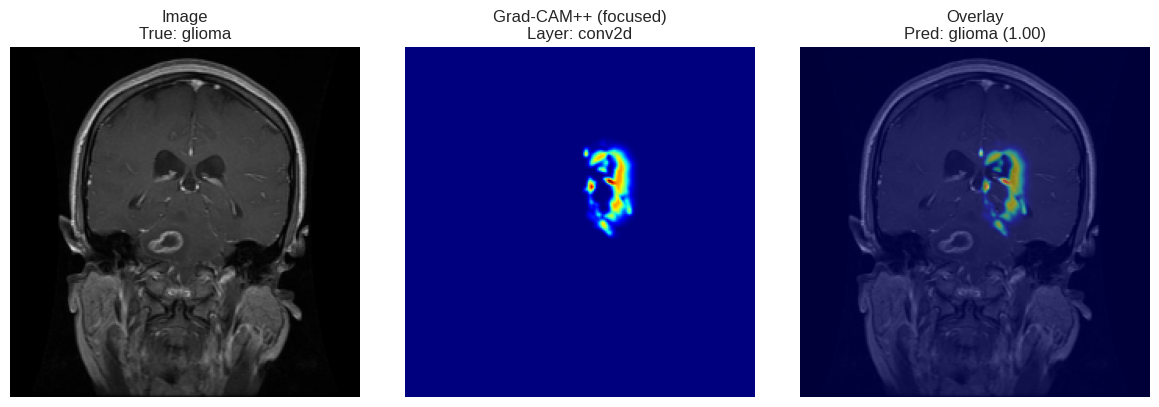

In [ ]:
# cell 43 - Grad-CAM++ focused v4 (deep-core focus + hemisphere gate + component filter)

import numpy as np, cv2, matplotlib.pyplot as plt

def mirror_about_midline(arr, mask):
    H, W = arr.shape
    ys, xs = np.indices((H, W))
    x_in = xs[mask>0]
    if x_in.size == 0:
        return np.zeros_like(arr, dtype=arr.dtype)
    cx = float(x_in.mean())
    j2 = np.round(2*cx - xs).astype(np.int32)
    inside = (j2 >= 0) & (j2 < W)
    mir = np.zeros_like(arr, dtype=arr.dtype)
    mir[inside] = arr[ys[inside], j2[inside]]
    return mir

def boundary_core_masks(mask, thickness=20):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (thickness, thickness))
    core = cv2.erode(mask.astype(np.uint8), k, iterations=1)
    cortical = (mask.astype(np.uint8) - core).astype(np.uint8)
    return core, cortical

def keep_dominant_component(hm, mask, min_area=60, open_ks=3, thr_pct=94):
    if not mask.any():
        return hm
    vals = hm[mask>0]
    if vals.size == 0:
        return hm
    thr = np.percentile(vals, thr_pct)
    bw = ((hm >= thr) & (mask>0)).astype(np.uint8)
    if open_ks and open_ks>1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ks, open_ks))
        bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k, iterations=1)
    cnts, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return hm
    H, W = hm.shape
    best = None
    for c in cnts:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x,y,w,h = cv2.boundingRect(c)
        per = max(cv2.arcLength(c, True), 1e-6)
        circ = (4.0*np.pi*area)/(per*per)
        ar = min(w,h)/max(w,h)
        extent = area / float(max(w*h,1))
        cmask = np.zeros((H,W), np.uint8); cv2.drawContours(cmask,[c],-1,1,-1)
        mean_h = float(hm[cmask>0].mean()) if cmask.any() else 0.0
        # penalize ribbon-like shapes (low extent, low ar), reward compactness
        score = mean_h * area * (0.5 + 0.25*ar + 0.25*circ) * (0.6 + 0.4*extent)
        if (best is None) or (score > best[0]):
            best = (score, cmask)
    if best is None:
        return hm
    keep = best[1].astype(np.float32)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    keep = cv2.dilate(keep, k, iterations=1)
    return hm * keep

def gradcampp_show(sample_idx=0, conv_name=None, percentile=97, border_trim=14,
                   alpha=0.45, save=False, cortical_th=20, rim_cut=0.43,
                   rim_power=2.6, mid_sigma=0.16, asym_gain=1.10):
    # image
    img = xtest[sample_idx]

    # prefer an earlier conv for sharper CAMs
    try:
        convs = list_conv_layers(model)  # from Cell 41
        if conv_name is None:
            conv_name = convs[-5] if len(convs) >= 5 else (convs[-4] if len(convs) >= 4 else convs[-2] if len(convs) >= 2 else convs[-1])
    except Exception:
        conv_name = None

    # Grad-CAM++ heatmap
    hm, probs = gradcampp_heatmap_bgr(img, model, layer_name=conv_name, class_index=None)  # from Cell 42

    # brain mask + distance transform
    mask = brain_mask_bgr(img)  # from Cell 41
    dt = cv2.distanceTransform((mask*255).astype(np.uint8), cv2.DIST_L2, 5).astype(np.float32)
    dt_norm = dt/(dt.max()+1e-6) if dt.max()>0 else dt

    # rim and midline suppression
    w_rim = np.clip((dt_norm - rim_cut) / max(1e-6, (1.0 - rim_cut)), 0, 1) ** rim_power
    ys, xs = np.indices(mask.shape)
    x_in = xs[mask>0]
    cx = float(x_in.mean()) if x_in.size else xs.shape[1]/2.0
    half_w = max((x_in.max()-x_in.min()) if x_in.size else xs.shape[1], 1.0)/2.0
    w_mid = 1.0 - np.exp(- (np.abs(xs-cx)/half_w)**2 / (2*(mid_sigma**2)))

    # core vs cortical weighting (favor deep core, strongly downweight cortical belt)
    core, cortical = boundary_core_masks(mask, thickness=cortical_th)
    w_coremap = (core>0).astype(np.float32)*1.0 + (cortical>0).astype(np.float32)*0.05

    # deep-core emphasis (ignore very rim-proximal areas)
    deep_core = (dt_norm > 0.45).astype(np.float32)

    # apply weights
    hm = hm * w_rim * w_mid * w_coremap * deep_core * mask

    # normalize inside mask + border trim
    hm = normalize_inside_mask(hm, mask, percentile=percentile, border_trim=border_trim)  # from Cell 41

    # brightness-guided boost inside deep core (helps ring-enhancing lesions)
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    if (mask>0).any():
        t = np.percentile(g[mask>0], 93)
        bright = ((g >= t) & (deep_core>0)).astype(np.float32)
        hm *= (0.60 + 0.40*bright)

    # strong asymmetry gating
    mir = mirror_about_midline(hm, mask)
    hm_asym = np.clip(hm - mir, 0, 1)
    hm_asym = normalize_inside_mask(hm_asym, mask, percentile=97, border_trim=border_trim)
    hm = np.clip(hm * (0.02 + asym_gain*hm_asym) * np.power(hm_asym+1e-6, 0.7), 0, 1)

    # hemisphere gating using deep-core energy
    left = (xs < cx) & (mask>0)
    right = (xs >= cx) & (mask>0)
    hL = float((hm * deep_core * left).sum())
    hR = float((hm * deep_core * right).sum())
    if hL >= hR:
        hm[right] *= 0.04
    else:
        hm[left] *= 0.04

    # keep dominant component only
    hm = keep_dominant_component(hm, mask, min_area=60, open_ks=3, thr_pct=94)

    # hard clip near-rim band
    hm[dt_norm < (rim_cut + 0.05)] *= 0.03

    # light smoothing for visuals
    hm = cv2.GaussianBlur(hm, (0,0), 0.9)

    # overlay
    ov = overlay_bgr(img, hm, alpha=alpha)  # from Cell 41

    # labels
    pred_id = int(np.argmax(probs))
    try:
        pred_name = inv_classes[pred_id]
        true_name = inv_classes[int(ytest[sample_idx])]
    except Exception:
        pred_name = str(pred_id); true_name = str(int(ytest[sample_idx]))

    # show
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(f"Image\nTrue: {true_name}"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(hm, cmap='jet'); plt.title(f"Grad-CAM++ (focused)\nLayer: {conv_name}"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(ov); plt.title(f"Overlay\nPred: {pred_name} ({probs[pred_id]:.2f})"); plt.axis('off')
    plt.tight_layout(); plt.show()

    if save:
        import os
        out = os.path.join(os.getcwd(), "xai_outputs"); os.makedirs(out, exist_ok=True)
        base = f"idx{sample_idx}_gcapp_v4_{conv_name}_pred{pred_name}_{probs[pred_id]:.2f}"
        cv2.imwrite(os.path.join(out, base+"_overlay_rgb.png"), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(out, base+"_heat_uint8.png"), (hm*255).astype(np.uint8))
        print("Saved to:", out)

    return hm, ov, probs

# Example run
print("Conv layers:", list_conv_layers(model))
_ = gradcampp_show(sample_idx=0, cortical_th=20, rim_cut=0.43, rim_power=2.6, mid_sigma=0.16,
                   percentile=97, border_trim=14, alpha=0.45, save=False)

In [ ]:
# cell 44 - Batch save XAI overlays

def save_xai_batch(start=0, end=12, conv=None):
    for i in range(start, min(end, len(xtest))):
        try:
            gradcampp_show(sample_idx=i, conv_name=conv, save=True)
        except Exception as e:
            print(f"Idx {i}: failed ->", e)

# Usage:
# save_xai_batch(0, 16)  # saves overlays for indices 0..15 into xai_outputs

Using output dir: /content/xai_outputs


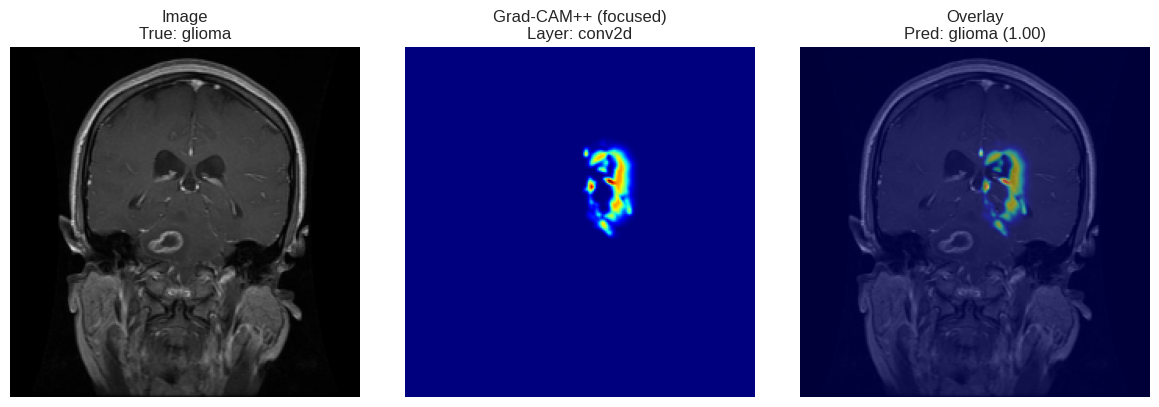

Saved to: /content/xai_outputs


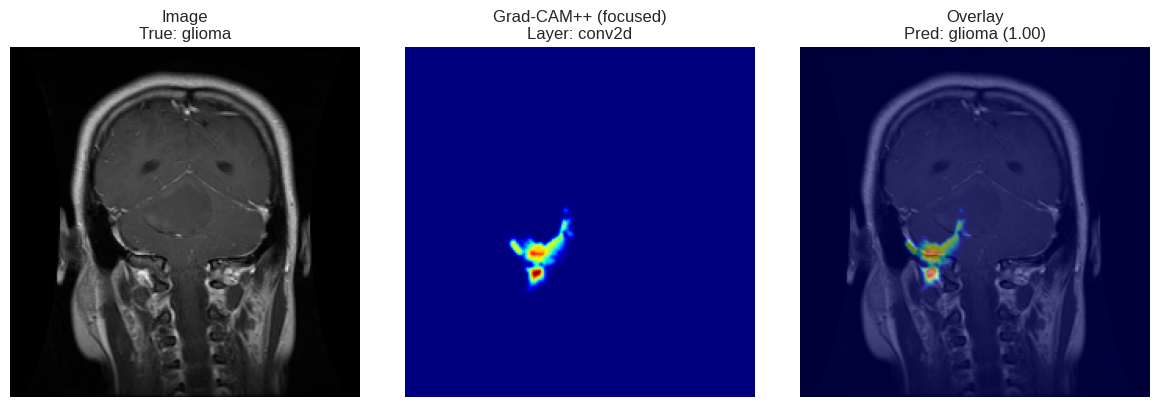

Saved to: /content/xai_outputs


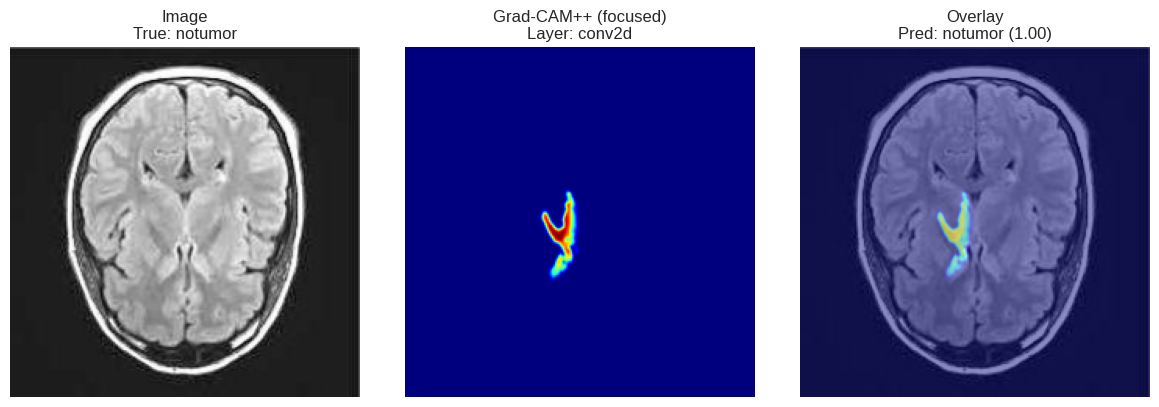

Saved to: /content/xai_outputs


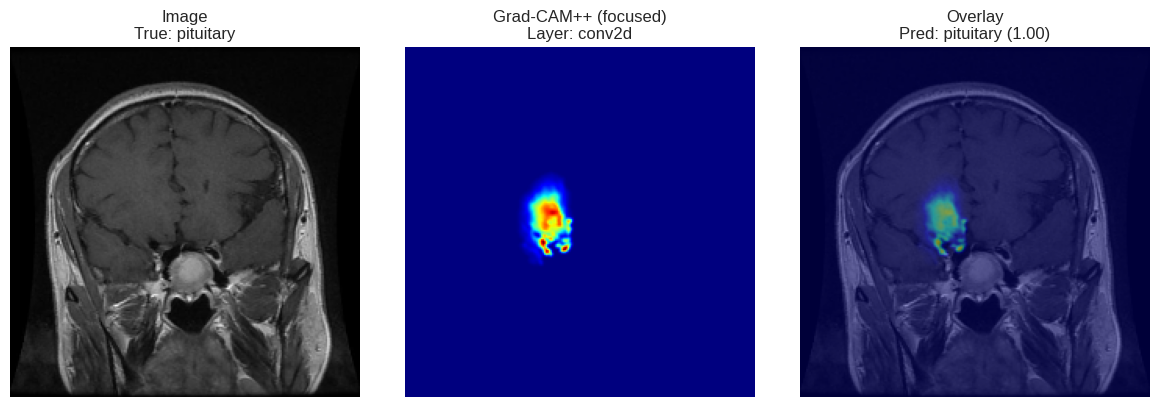

Saved to: /content/xai_outputs


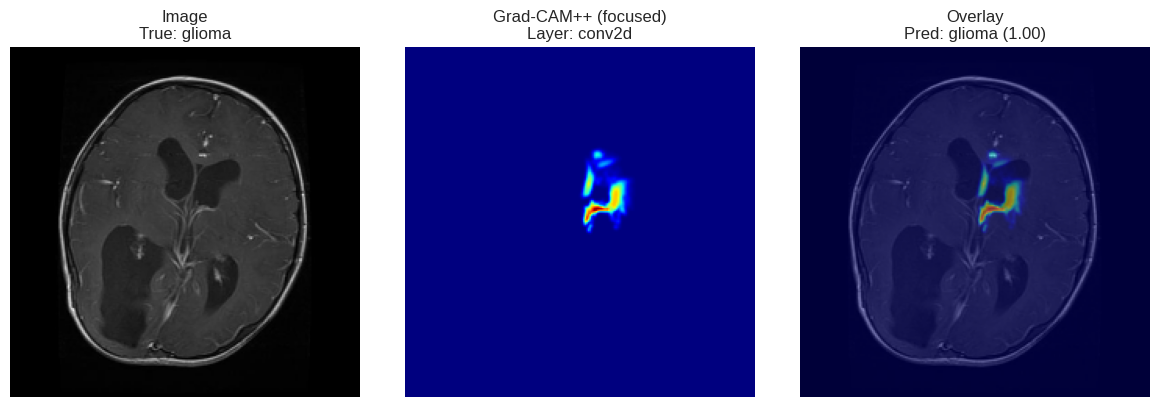

Saved to: /content/xai_outputs


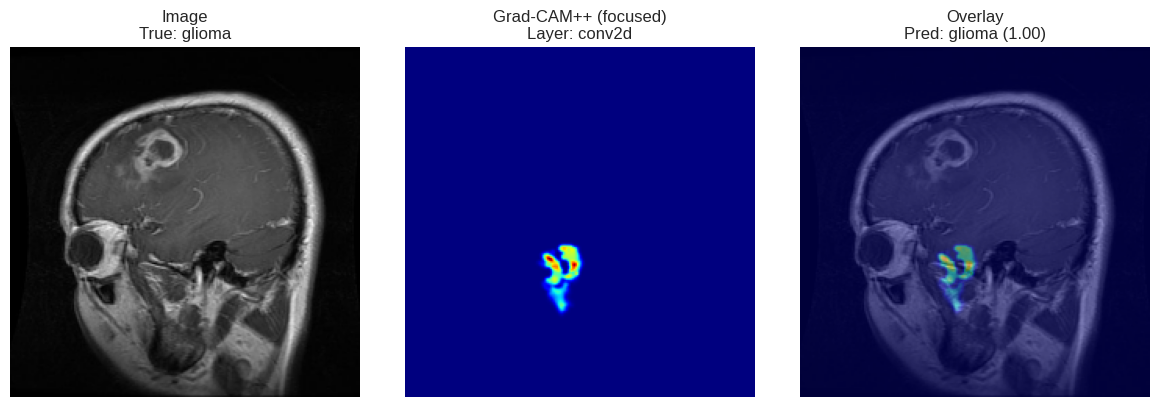

Saved to: /content/xai_outputs


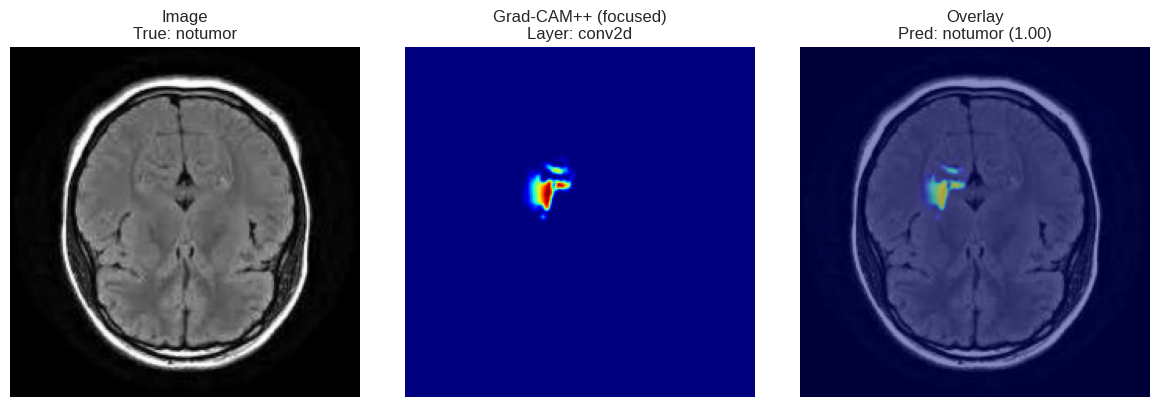

Saved to: /content/xai_outputs


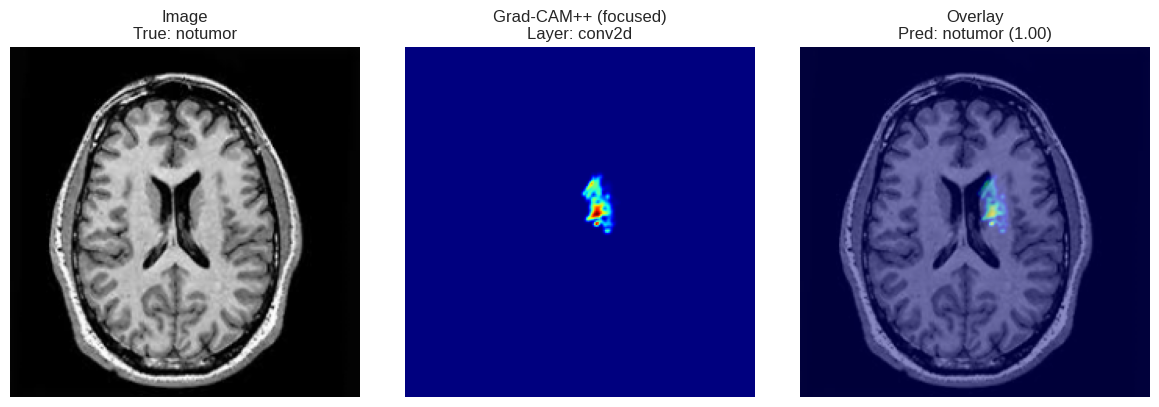

Saved to: /content/xai_outputs


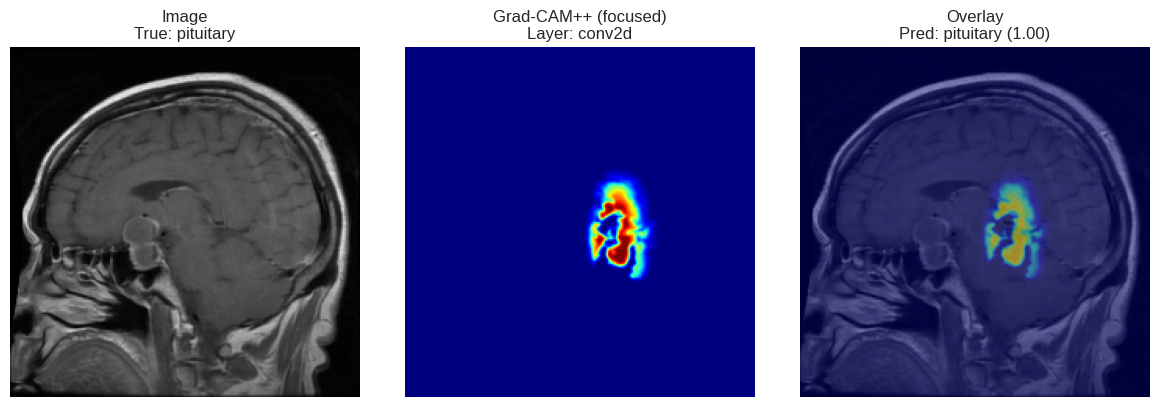

Saved to: /content/xai_outputs


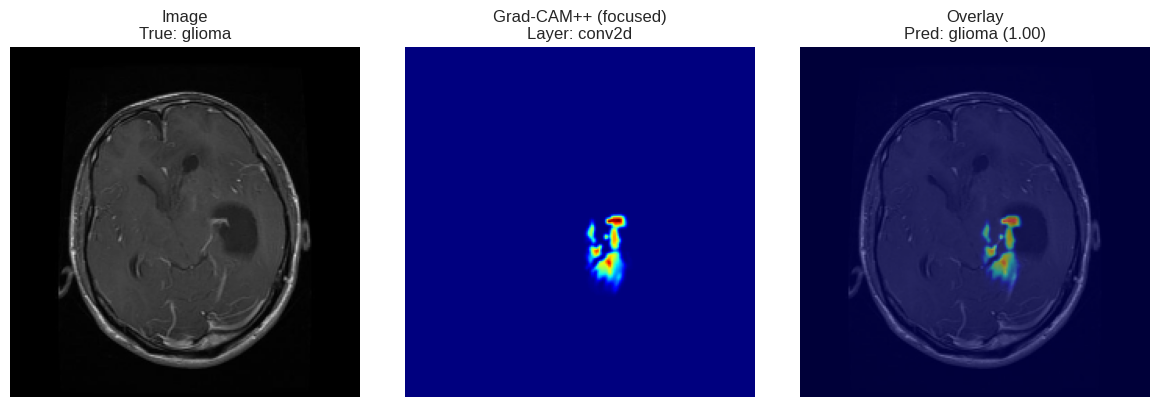

Saved to: /content/xai_outputs


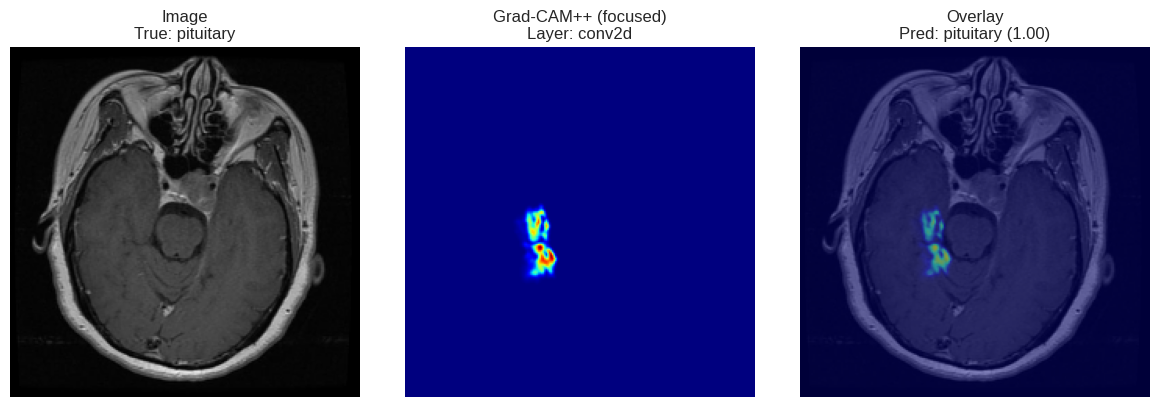

Saved to: /content/xai_outputs


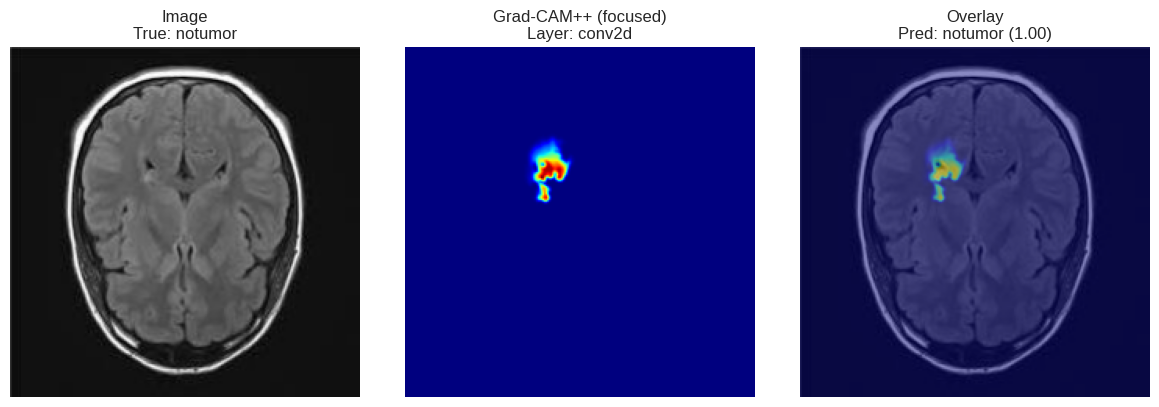

Saved to: /content/xai_outputs


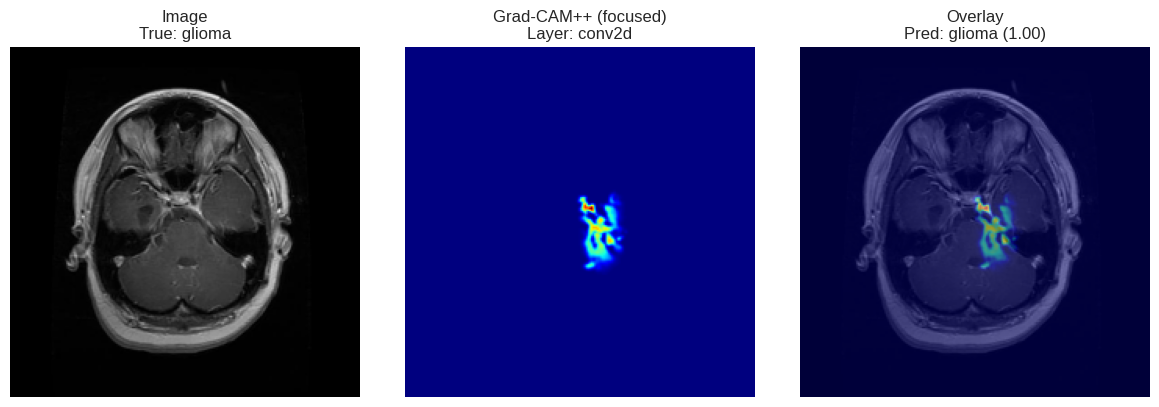

Saved to: /content/xai_outputs


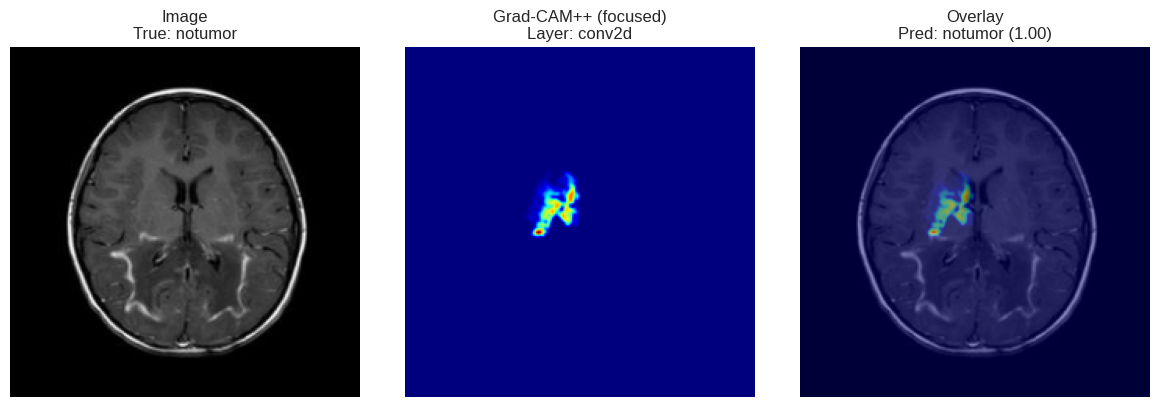

Saved to: /content/xai_outputs


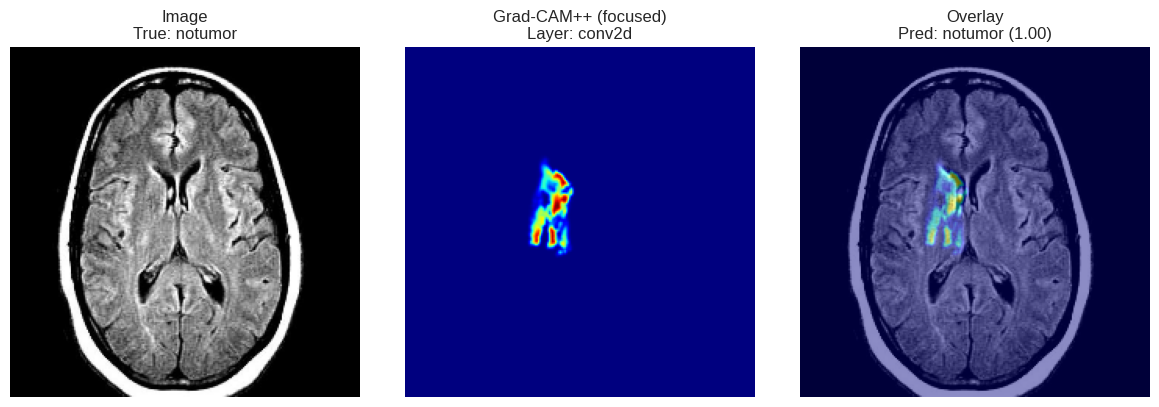

Saved to: /content/xai_outputs


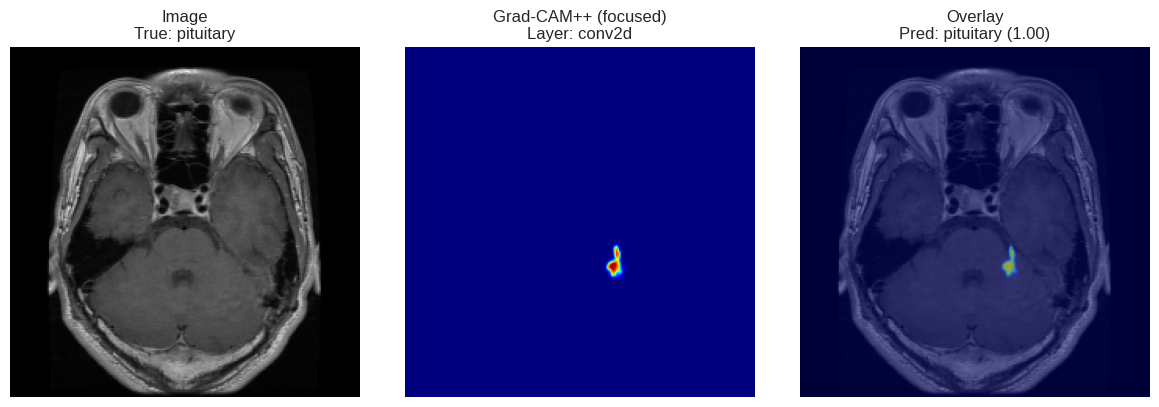

Saved to: /content/xai_outputs


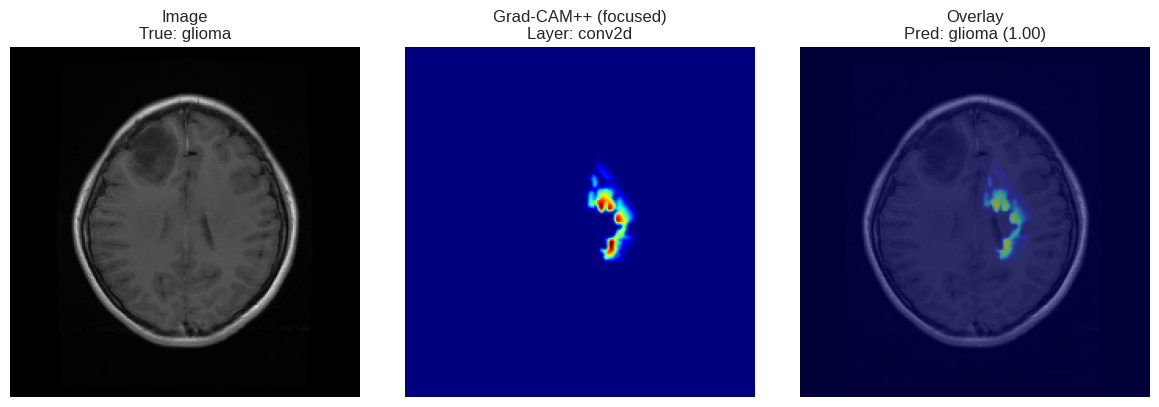

Saved to: /content/xai_outputs


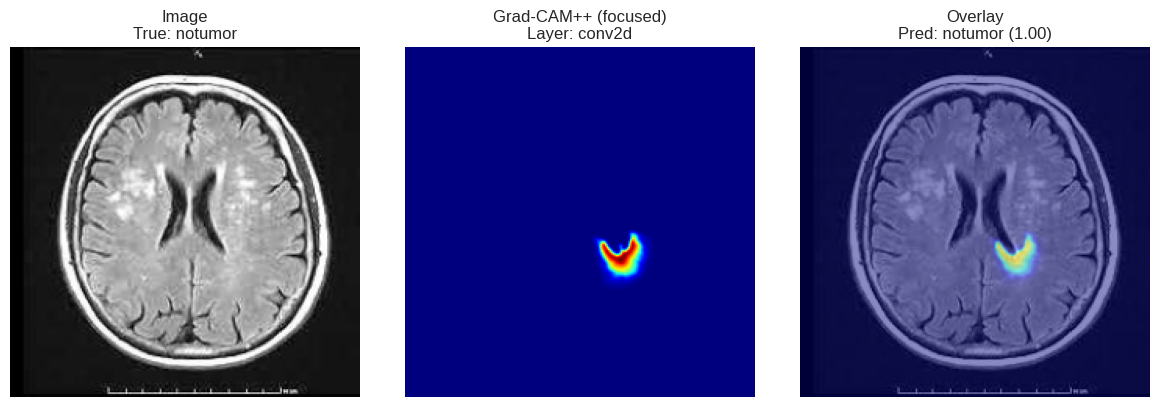

Saved to: /content/xai_outputs


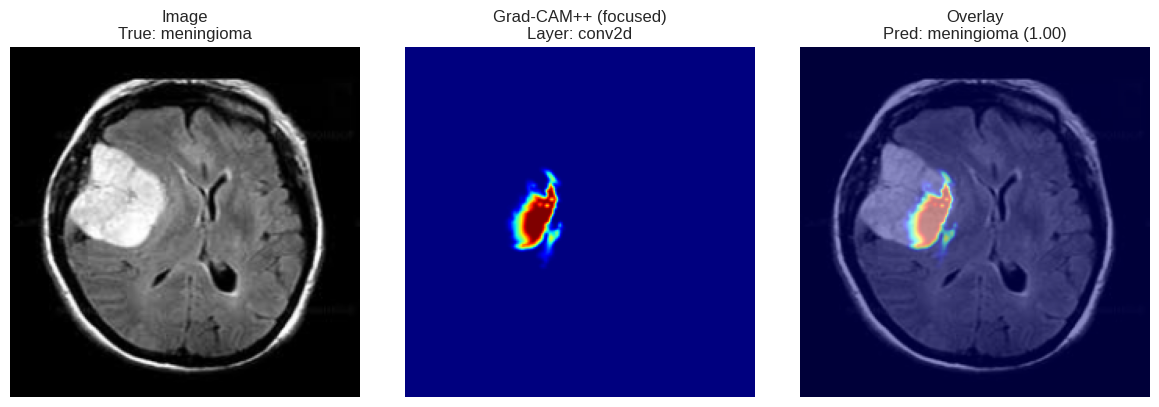

Saved to: /content/xai_outputs


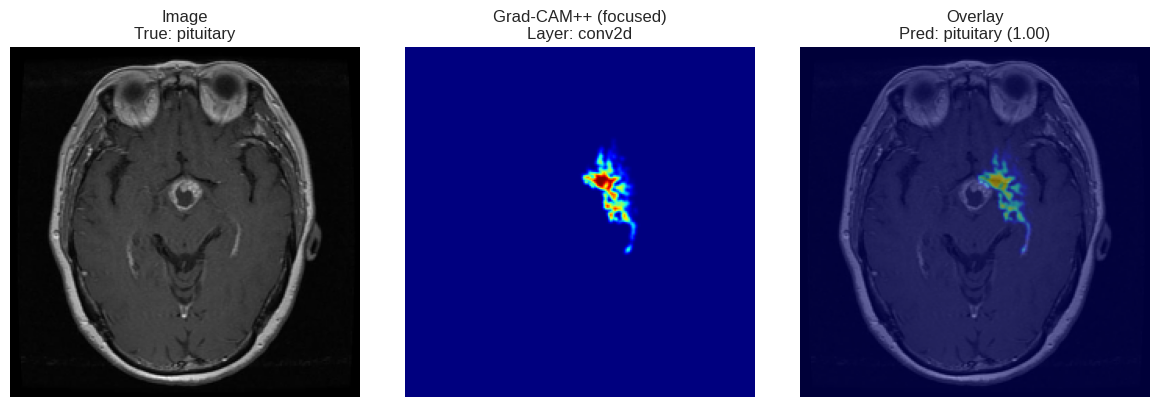

Saved to: /content/xai_outputs


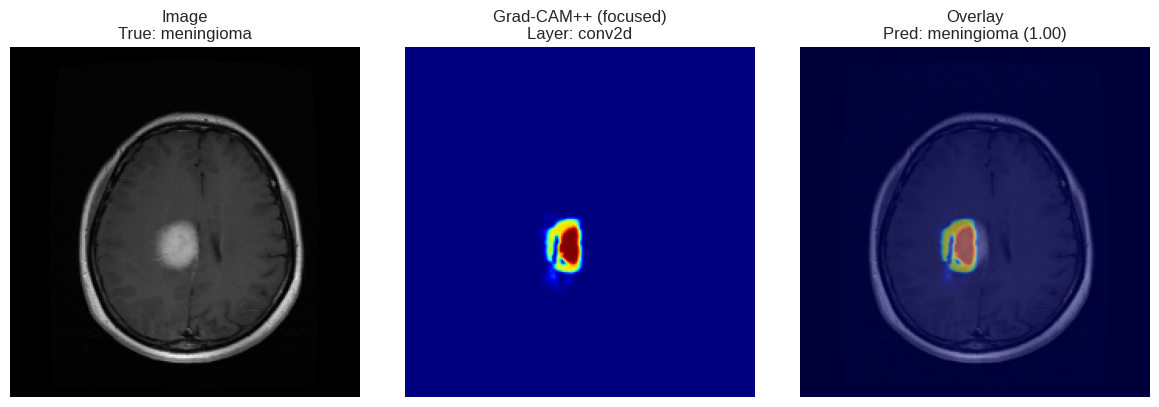

Saved to: /content/xai_outputs


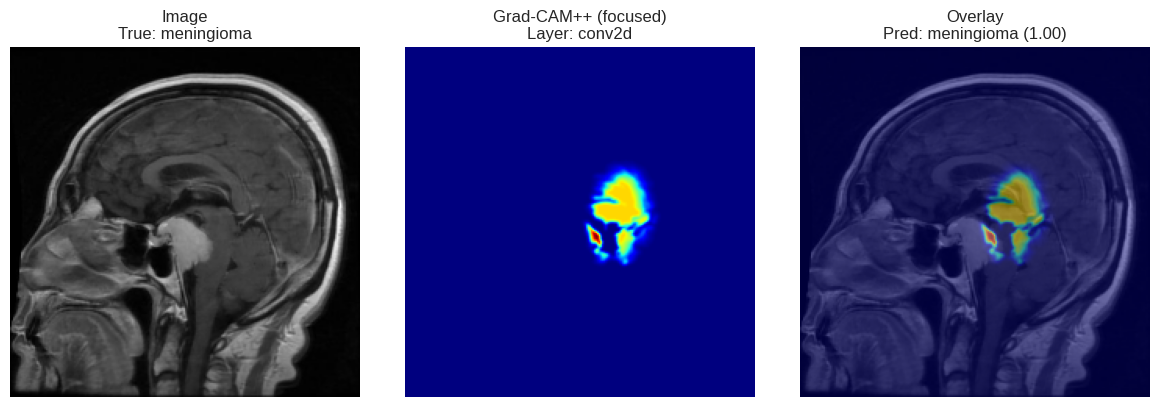

Saved to: /content/xai_outputs


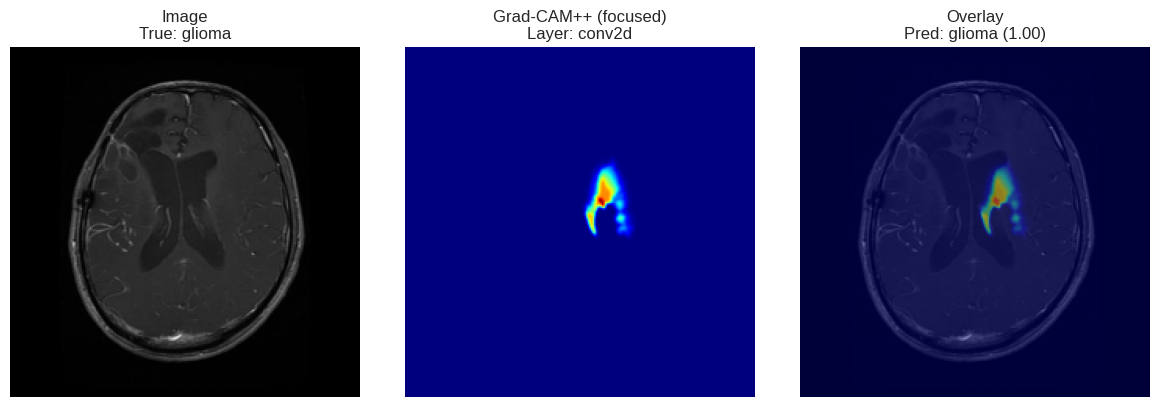

Saved to: /content/xai_outputs


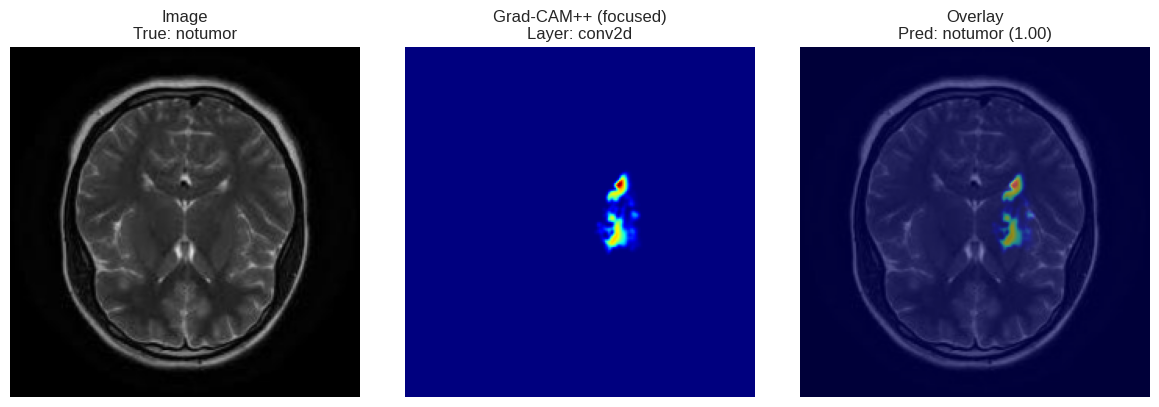

Saved to: /content/xai_outputs
Overlays dir: /content/xai_outputs
Saved log: /content/xai_outputs/xai_log.csv


In [ ]:
# cell 45 - Save overlays for a batch and log a CSV (robust + fallback)

import os, pandas as pd, numpy as np, tempfile
from pathlib import Path

def pick_out_dir():
    # Try project root, then current dir, then home, else temp
    candidates = []
    proj = Path(r"D:\New folder (2)\BRAIN TUMAR")
    if proj.exists(): candidates.append(proj / "xai_outputs")
    candidates.append(Path.cwd() / "xai_outputs")
    candidates.append(Path.home() / "xai_outputs")
    for p in candidates:
        try:
            p.mkdir(parents=True, exist_ok=True)
            return p
        except Exception as e:
            print(f"Cannot create {p}: {e}")
    tmp = Path(tempfile.mkdtemp(prefix="xai_outputs_"))
    print("Fallback temp dir:", tmp)
    return tmp / "xai_outputs"

OUT = pick_out_dir()
print("Using output dir:", OUT)

def save_xai_with_log(start=0, end=24, conv=None):
    rows = []
    old_cwd = Path.cwd()

    # Ensure gradcampp_show (Cell 43) saves into OUT by setting cwd to OUT.parent
    if OUT.name.lower() == "xai_outputs":
        base_dir = OUT.parent
        overlays_dir = OUT
    else:
        base_dir = OUT
        overlays_dir = OUT / "xai_outputs"
    overlays_dir.mkdir(parents=True, exist_ok=True)

    try:
        os.chdir(base_dir)  # Cell 43 saves to os.getcwd()/xai_outputs
        for i in range(start, min(end, len(xtest))):
            try:
                hm, ov, probs = gradcampp_show(sample_idx=i, conv_name=conv, save=True)
                pred_id = int(np.argmax(probs))
                true_id = int(ytest[i])
                try:
                    pred_name = inv_classes[pred_id]
                    true_name = inv_classes[true_id]
                except Exception:
                    pred_name, true_name = str(pred_id), str(true_id)
                rows.append({
                    "index": i,
                    "true_id": true_id, "true_name": true_name,
                    "pred_id": pred_id, "pred_name": pred_name,
                    "pred_prob": float(probs[pred_id])
                })
            except Exception as e:
                print(f"Idx {i}: failed -> {e}")
    finally:
        os.chdir(old_cwd)

    df = pd.DataFrame(rows)
    csv_path = overlays_dir / "xai_log.csv"
    df.to_csv(csv_path, index=False)
    print("Overlays dir:", overlays_dir)
    print("Saved log:", csv_path)

# Example: first 24 test images
save_xai_with_log(0, 24)